In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
e_data = pd.read_csv("energy_dataset.csv")
w_data = pd.read_csv("weather_features.csv")

In [3]:
e_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [4]:
w_data.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [5]:
e_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [6]:
w_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

## Exploratory Data Analysis for Insights

### Q. How does consumption vary by hour of day?

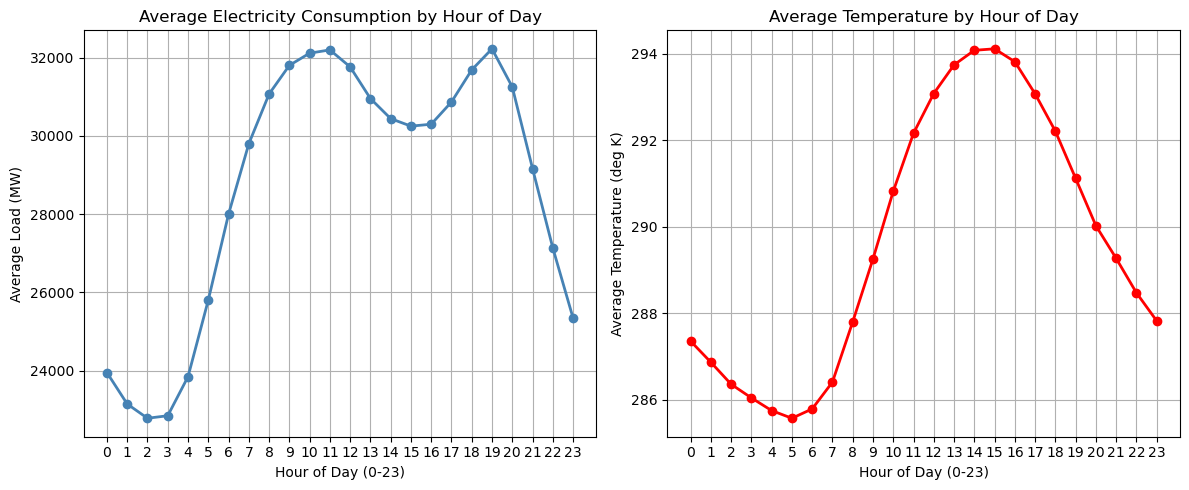

In [7]:
e_copy = e_data.copy()
w_copy = w_data.copy()

e_copy['hour'] = pd.to_datetime(e_copy['time'], utc=True).dt.hour
hour_avg = e_copy.groupby('hour')['total load actual'].mean()

w_copy['hour'] = pd.to_datetime(w_copy['dt_iso'], utc=True).dt.hour
temp_avg = w_copy.groupby('hour')['temp'].mean()

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))

axes[0].plot(hour_avg.index,
         hour_avg.values,
         marker = 'o',
         linewidth = 2,
         color = 'steelblue')

#Plot 1: Electricity Consumption
axes[0].set_title('Average Electricity Consumption by Hour of Day')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Average Load (MW)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True)


# Plot 2: Temperature
axes[1].plot(temp_avg.index,
         temp_avg.values,
         marker = 'o',
         linewidth = 2,
         color = 'red')

axes[1].set_title('Average Temperature by Hour of Day')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_ylabel('Average Temperature (deg K)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True)

# Global Figure adjustments (Call once after defining all plots)
plt.tight_layout()
plt.savefig('hourly_patterns.png', dpi=150)

## Observations:
- Average load or electricity consumption is more than 28000 MW from 6:00 in morning to 22:00 evening. Electricity consumption peaks from 9:00 to 12:00, during work hours. Then again peaks from 18:00 to 20:00 in the evening.
- Electricity consumption follows a clear bimodal daily pattern with a primary peak during morning working hours and a secondary peak during evening hours.
- Despite temperature peaking at 3PM, electricity consumption dips at this hour, suggesting that human activity patterns — specifically the afternoon slowdown in Spanish culture — outweigh the effect of electricity demand on overall grid load.
- Electricity consumption follows a bimodal daily pattern — the first peak during morning hours (9AM-12PM) is driven by industrial and commercial activity, while the second peak during evening hours (6PM-9PM) reflects residential demand from cooking, lighting, heating and entertainment.

## Q. How does consumption vary by season?

In [8]:
e_copy['month'] = pd.to_datetime(e_copy['time'], utc=True).dt.month
w_copy['month'] = pd.to_datetime(w_copy['dt_iso'], utc=True).dt.month


month_to_season = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring',
    5: 'spring', 6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
}

# 2. Create the new season column
w_copy['season'] = w_copy['month'].map(month_to_season)

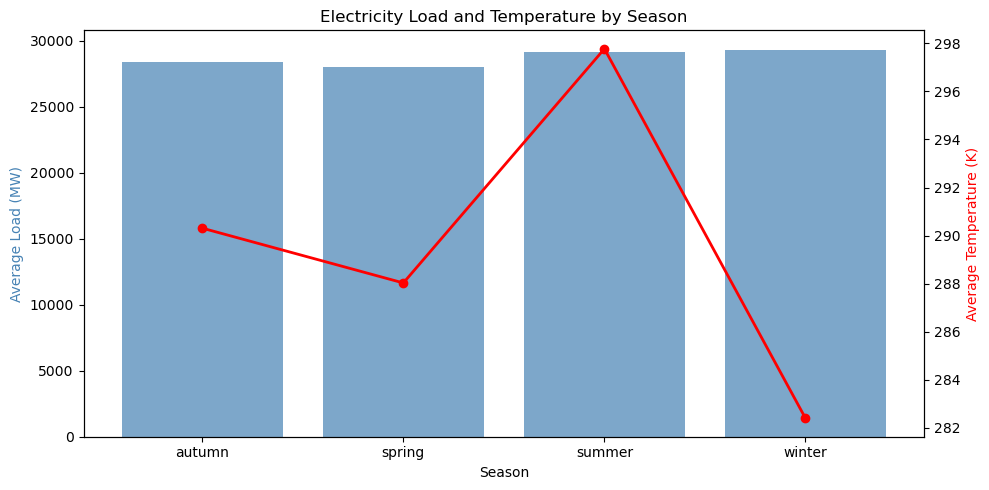

In [9]:
daily_load = e_copy.groupby(['month'])['total load actual'].mean().reset_index()
daily_weather = w_copy.groupby(['month','season'])['temp'].mean().reset_index()
season_load = pd.merge(daily_load,daily_weather,on = 'month', how = 'left')
season_load_status = season_load.groupby('season')['total load actual'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for load
ax1.bar(season_load_status['season'], 
        season_load_status['total load actual'],
        color='steelblue', alpha=0.7, label='Avg Load')
ax1.set_ylabel('Average Load (MW)', color='steelblue')
ax1.set_xlabel('Season')

# Line chart for temperature on second axis
ax2 = ax1.twinx() #To add another y-axis on the same plot
season_temp = season_load.groupby('season')['temp'].mean().reset_index()
ax2.plot(season_temp['season'], 
         season_temp['temp'],
         color='red', marker='o', linewidth=2, label='Avg Temp')
ax2.set_ylabel('Average Temperature (K)', color='red')

plt.title('Electricity Load and Temperature by Season')
plt.tight_layout()
plt.savefig('seasonal_load_temperature.png', dpi=150)
plt.show()

## Observations:
- Average electricity consumption is same in all the seasons.
- Electricity demand in winter is slightly above the electricity demand in summer due to increase in heating appliances usage.
- Electricity consumption remains relatively stable across seasons, suggesting industrial baseline load dominates over residential temperature-driven demand.


In [10]:
e_copy['day_type'] = pd.to_datetime(e_copy['time'], utc = True).dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
e_copy['day_type']

0        Weekday
1        Weekday
2        Weekday
3        Weekday
4        Weekday
          ...   
35059    Weekday
35060    Weekday
35061    Weekday
35062    Weekday
35063    Weekday
Name: day_type, Length: 35064, dtype: object

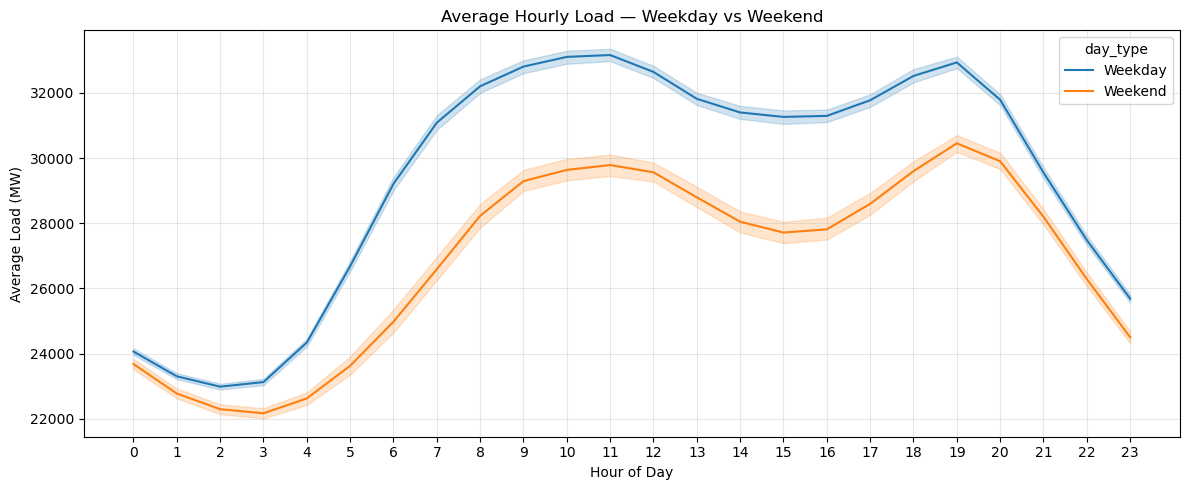

In [11]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=e_copy, 
             x='hour', 
             y='total load actual',
             hue='day_type',
             estimator='mean')

plt.title('Average Hourly Load — Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load (MW)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weekday_weekend_load.png', dpi=150)
plt.show()

## Observation:
- Weekday and weekend electricity consumption follow identical bimodal patterns with two peaks — first peak around 10-11AM and second peak around 19-20PM. However weekday load is consistently higher than weekend load throughout all hours of the day.
- The similar pattern shape suggests both peaks are driven by human activity rather than purely industrial activity — morning peak reflects household and commercial activity starting simultaneously, while evening peak reflects residential cooking, lighting and entertainment which remains consistent regardless of day type.
- Lower weekend load confirms industrial and commercial activity contributes a constant baseline load on weekdays — evidenced by the uniform downward shift of the entire weekend curve rather than just the morning peak disappearing. This justifies inclusion of day of week as a feature in the forecasting model

### Q. What is the relationship between consumption and price? 

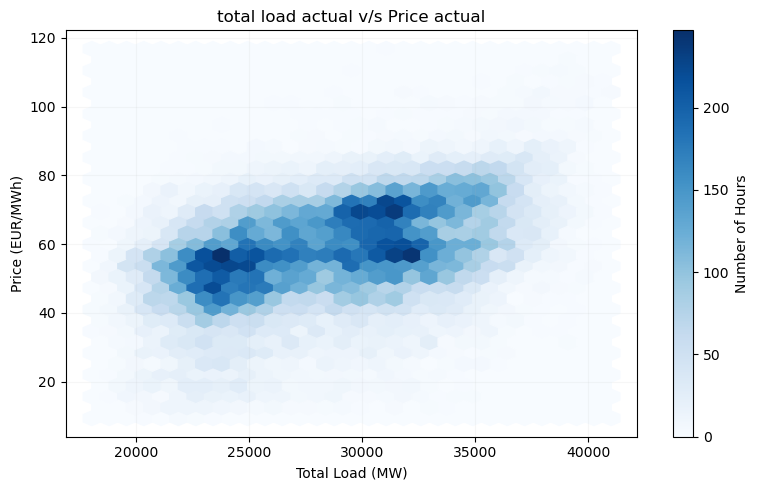

In [12]:
plt.figure(figsize=(8, 5))

plt.hexbin(e_copy['total load actual'], e_copy['price actual'], 
           gridsize=30, cmap='Blues')
plt.colorbar(label='Number of Hours')
plt.title('total load actual v/s Price actual')
plt.ylabel('Price (EUR/MWh)')
plt.xlabel('Total Load (MW)')
plt.grid(True, alpha = 0.1)
plt.tight_layout()
plt.savefig('consumption_vs_price_hexbin.png', dpi=150)
plt.show()

In [13]:
correlation = e_copy['total load actual'].corr(e_copy['price actual'])
print(f'Correlation: {correlation:.3f}')

Correlation: 0.436


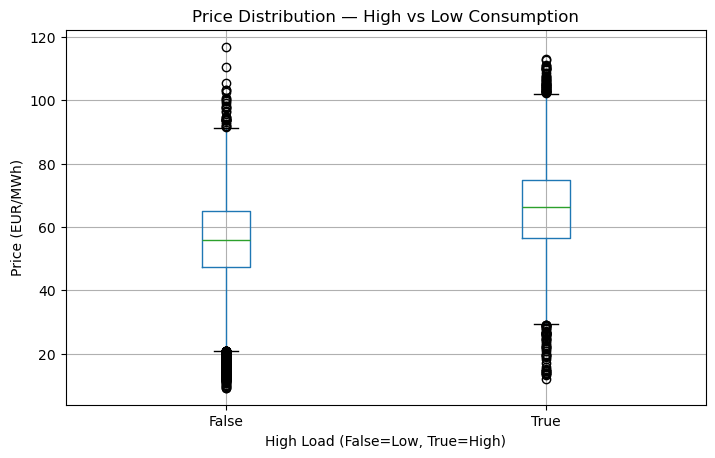

In [14]:
# Find high consumption low price hours
e_copy['high_load'] = e_copy['total load actual'] > e_copy['total load actual'].quantile(0.75)

# Compare price distribution between high and low load periods
e_copy.boxplot(column='price actual', by='high_load', figsize=(8,5))
plt.title('Price Distribution — High vs Low Consumption')
plt.suptitle('')
plt.xlabel('High Load (False=Low, True=High)')
plt.ylabel('Price (EUR/MWh)')
plt.show()

### Observations:
- Pearson correlation of 0.436 indicates moderate positive relationship between consumption and price. Hexbin plot shows highest density between 30,000-33,000 MW load and 50-70 EUR/MWh price range.
- Price is not always high durng peak load.
- The moderate rather than strong correlation suggests renewable generation acts as a price suppressor — increasing renewable supply reduces dependence on expensive fossil fuel plants even during high demand periods. Price outliers beyond 80 EUR/MWh indicate occasional spikes during periods of high demand and low renewable availability.

### Q. How does temperature affect consumption?

Correlation: 0.203


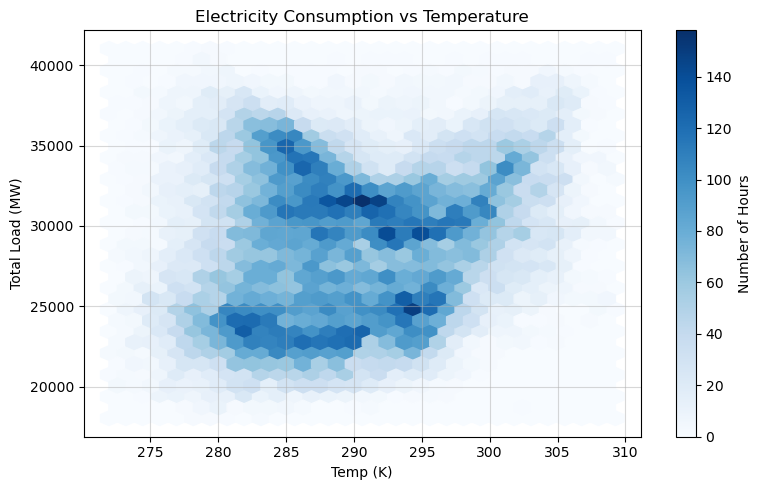

In [15]:
w_hourly = w_copy.groupby('dt_iso')['temp'].mean().reset_index()

merged = pd.merge(e_copy, 
                  w_hourly,
                  left_on='time',
                  right_on='dt_iso',
                  how='left')

corr = merged['temp'].corr(merged['total load actual'])
print(f'Correlation: {corr:.3f}')

plt.figure(figsize=(8, 5))

plt.hexbin(merged['temp'], merged['total load actual'],
           gridsize=30, cmap='Blues')
plt.colorbar(label='Number of Hours')
plt.title('Electricity Consumption vs Temperature')
plt.xlabel('Temp (K)')
plt.ylabel('Total Load (MW)')
plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.savefig('consumption_vs_temp.png', dpi=150)
plt.show()

## Observations:
- Pearson correlation is 0.203, which tells weak linear relationship between Total load and temperature.
- U-shaped total load and temp  and number of hour density in the middle indicate electricity consumption is less to moderate during average temeprature. However, Consumption increases during less and high temperature but number of hour density for these extreme temperature is less dense.
- This suggests electricity consumption is driven by heating and cooling needs at temperature extremes. High density at moderate temperatures reflects Spain's Mediterranean climate where extreme temperatures are infrequent. Weak correlation confirms temperature is a secondary predictor — hour of day and generation mix are stronger price drivers

### Q. What are the sources of electricity generation in spain?

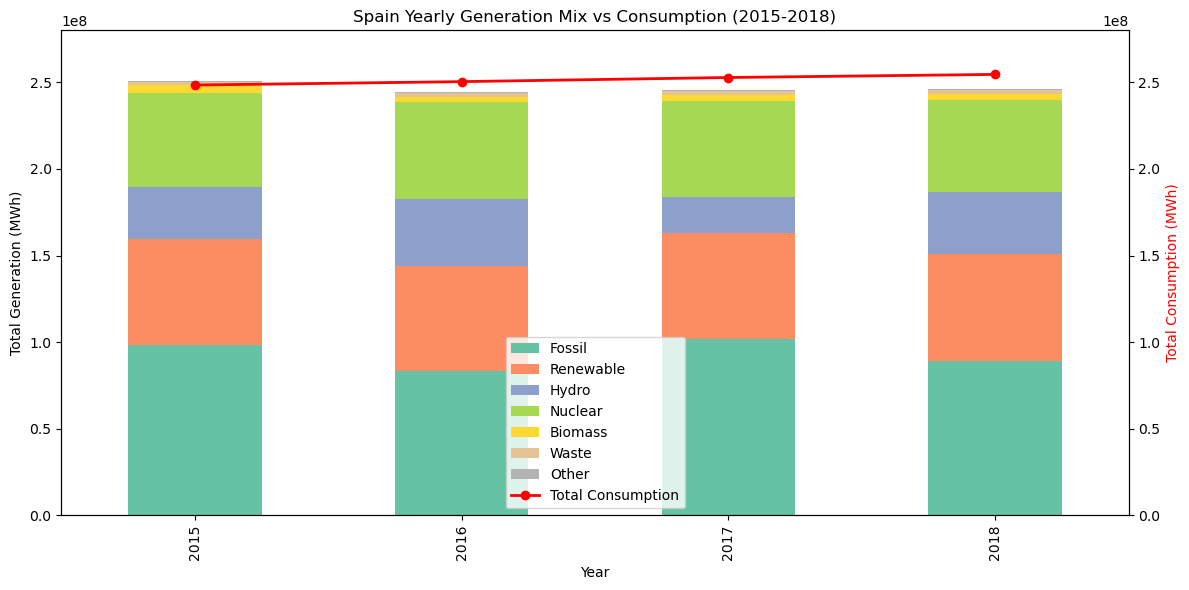

In [16]:
e_copy['year'] = pd.to_datetime(e_copy['time'], utc = True).dt.year

generation_cols = [col for col in e_copy.columns 
                   if col.startswith('generation')]

e_copy = e_copy[e_copy['year'].isin([2015, 2016, 2017, 2018])]

e_copy[generation_cols] = e_copy[generation_cols].fillna(0)

yearly_generation = e_copy.groupby('year')[generation_cols].sum() #Calculating yearly sum

e_copy['total load actual'] = e_copy['total load actual'].fillna(e_copy['total load forecast'])
yearly_consumption = e_copy.groupby('year')['total load actual'].sum() #Calculating yearly total consumption

# Create grouped categories
yearly_generation['Fossil'] = (
    yearly_generation['generation fossil brown coal/lignite'] +
    yearly_generation['generation fossil coal-derived gas'] +
    yearly_generation['generation fossil gas'] +
    yearly_generation['generation fossil hard coal'] +
    yearly_generation['generation fossil oil'] +
    yearly_generation['generation fossil oil shale'] +
    yearly_generation['generation fossil peat']
)

yearly_generation['Renewable'] = (
    yearly_generation['generation solar'] +
    yearly_generation['generation wind onshore'] +
    yearly_generation['generation wind offshore'] +
    yearly_generation['generation other renewable'] +
    yearly_generation['generation geothermal'] +
    yearly_generation['generation marine']
)

yearly_generation['Hydro'] = (
    yearly_generation['generation hydro water reservoir'] +
    yearly_generation['generation hydro run-of-river and poundage'] +
    yearly_generation['generation hydro pumped storage aggregated']
)

yearly_generation['Nuclear'] = (
    yearly_generation['generation nuclear']
)

yearly_generation['Biomass'] = (
    yearly_generation['generation biomass']
)

yearly_generation['Waste'] = (
    yearly_generation['generation waste']
)

yearly_generation['Other'] = (
    yearly_generation['generation other']
)

# Keep only grouped columns
plot_cols = ['Fossil', 'Renewable', 'Hydro', 'Nuclear', 'Biomass', 'Waste', 'Other']
plot_data = yearly_generation[plot_cols]


fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot Stacked Bars on ax1
plot_data.plot(kind='bar', 
               stacked=True, 
               ax=ax1, 
               colormap='Set2')

# 2. Create ax2 and plot Consumption Line
ax2 = ax1.twinx()
ax2.plot(range(len(yearly_consumption)), 
         yearly_consumption.values, 
         color='red', 
         marker='o',
         linewidth=2,
         label='Total Consumption')


# We find the max of the stacked bar totals vs the max of consumption values
max_val = max(plot_data.sum(axis=1).max(), yearly_consumption.max())
buffer = max_val * 0.10 # Add 10% padding so elements do not touch the top border

ax1.set_ylim(0, max_val + buffer)
ax2.set_ylim(0, max_val + buffer)


ax1.set_xlabel('Year')
ax1.set_ylabel('Total Generation (MWh)')
ax2.set_ylabel('Total Consumption (MWh)', color='red')
ax1.set_xlim(-0.5, len(plot_data) - 0.5)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center')

plt.title('Spain Yearly Generation Mix vs Consumption (2015-2018)')
plt.tight_layout()
plt.savefig('yearly_generation_consumption.png', dpi=150)
plt.show()


### Observations:
- Every year majority of the power is generated from fossils, then comes renewables, Nuclear and Hydro.
- All power generated is completely consumed. No surplus energy left.
- Total power consumed treand is slightly increasing upward with the year, indicating increase in the demand of electricity. However, power generation is slightly decreasing.

### Q. How Has Renewable Generation Varied Over Time?

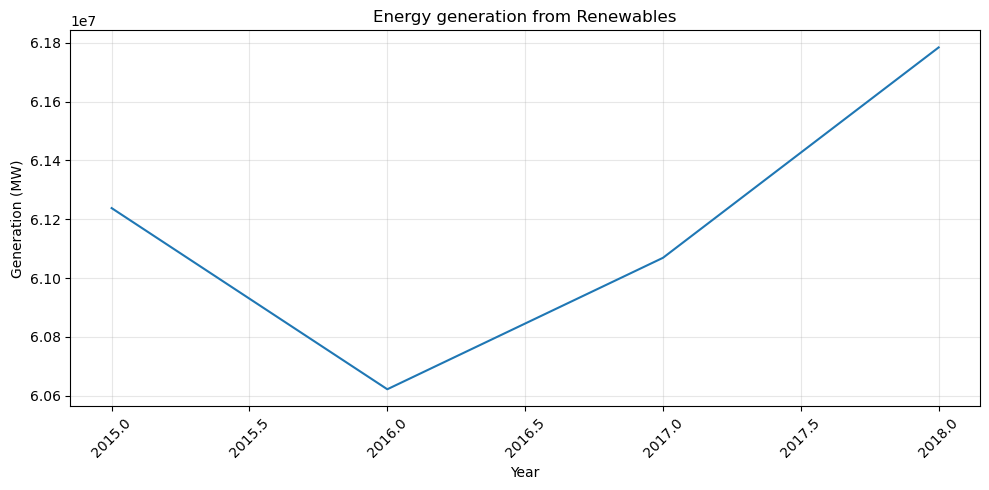

In [17]:
renewable_trend = yearly_generation['Renewable'].reset_index()

plt.figure(figsize=(10, 5))

plt.plot(renewable_trend['year'], 
             renewable_trend['Renewable'])

plt.title('Energy generation from Renewables')
plt.xlabel('Year')
plt.ylabel('Generation (MW)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('renewable_energy_generation.png', dpi=150)
plt.show()

## Observation:
- Power generation from renewables showed decreasing trend from 2015 and reached to its lowest in 2016. However, power contribution from renewables has started to increase from 2016 onward and crossed the 2015 power generation records.

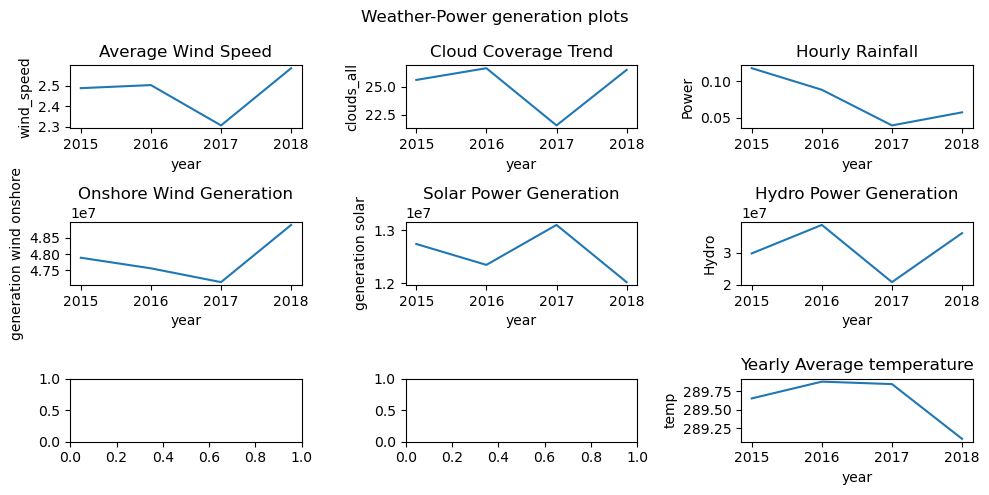

In [18]:
w_copy['year'] = pd.to_datetime(w_copy['dt_iso'], utc = True).dt.year

w_copy = w_copy[w_copy['year'].isin([2015, 2016, 2017, 2018])]
# Compare wind speed year wise
yearly_wind = w_copy.groupby('year')['wind_speed'].mean().reset_index()

# Compare cloud coverage year wise
yearly_clouds = w_copy.groupby('year')['clouds_all'].mean().reset_index()

# Compare rainfall year wise
yearly_rain = w_copy.groupby('year')['rain_1h'].mean().reset_index()

# yearly electricity generation from wind
yearly_wind_generation = yearly_generation['generation wind onshore'].reset_index()

# yearly electricity generation from solar
yearly_solar_generation = yearly_generation['generation solar'].reset_index()

# yearly electricity generation from wind
yearly_hydro_generation = yearly_generation['Hydro'].reset_index()

#yearly average temeprature
yearly_average_temp = w_copy.groupby('year')['temp'].mean().reset_index()


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10,5))

axes[0][0].plot(yearly_wind['year'], yearly_wind['wind_speed'])
axes[0][0].set_xlabel('year')
axes[0][0].set_ylabel('wind_speed')
axes[0][0].set_title('Average Wind Speed')


axes[0][1].plot(yearly_clouds['year'], yearly_clouds['clouds_all'])
axes[0][1].set_xlabel('year')
axes[0][1].set_ylabel('clouds_all')
axes[0][1].set_title('Cloud Coverage Trend')


axes[0][2].plot(yearly_rain['year'], yearly_rain['rain_1h'])
axes[0][2].set_xlabel('year')
axes[0][2].set_ylabel('Power')
axes[0][2].set_title('Hourly Rainfall')


axes[1][0].plot(yearly_wind_generation['year'], yearly_wind_generation['generation wind onshore'])
axes[1][0].set_xlabel('year')
axes[1][0].set_ylabel('generation wind onshore')
axes[1][0].set_title('Onshore Wind Generation')


axes[1][1].plot(yearly_solar_generation['year'], yearly_solar_generation['generation solar'])
axes[1][1].set_xlabel('year')
axes[1][1].set_ylabel('generation solar')
axes[1][1].set_title('Solar Power Generation')


axes[1][2].plot(yearly_hydro_generation['year'], yearly_hydro_generation['Hydro'])
axes[1][2].set_xlabel('year')
axes[1][2].set_ylabel('Hydro')
axes[1][2].set_title('Hydro Power Generation')


axes[2][2].plot(yearly_average_temp['year'], yearly_average_temp['temp'])
axes[2][2].set_xlabel('year')
axes[2][2].set_ylabel('temp')
axes[2][2].set_title('Yearly Average temperature')

plt.suptitle('Weather-Power generation plots', x=0.5, y=0.98) 
plt.tight_layout()
plt.savefig('weather yearwise.png', dpi=150)
plt.show()

## Observations:
- Power generation by winds is lowest in 2017, as could be indicated by lowest average wind speed among all years.
- Highest cloud coverage in 2016 reduced the solar panels efficiency, while lowest cloud coverage in 2017 resulted in maximum solar generation. Also, Solar power generation reached to its lowest in 2018 despite cloud coverage returning to 2016 level. This divergence suggest additional factors beyond cloud coverage may be influencing solar output — potentially including solar panel degradation over time, grid curtailment, or reduced sunshine hours. Further investigation with panel efficiency data would be needed to confirm this hypothesis.. 
- Hourly rainfall and hydro power generation is also lowest in 2017. Also Average temperature is also highest in 2016 and 2017.
- All these meteorological factors also indicate 2017 is the hottest among all year, that's why rainfall is least.
- Meteorological factors directly explain year-on-year variation in renewable generation — wind speed drives onshore wind output, cloud coverage inversely affects solar efficiency, and rainfall determines hydro reservoir levels. This confirms weather variables are essential features for renewable generation forecasting, validating their inclusion in the ML model.

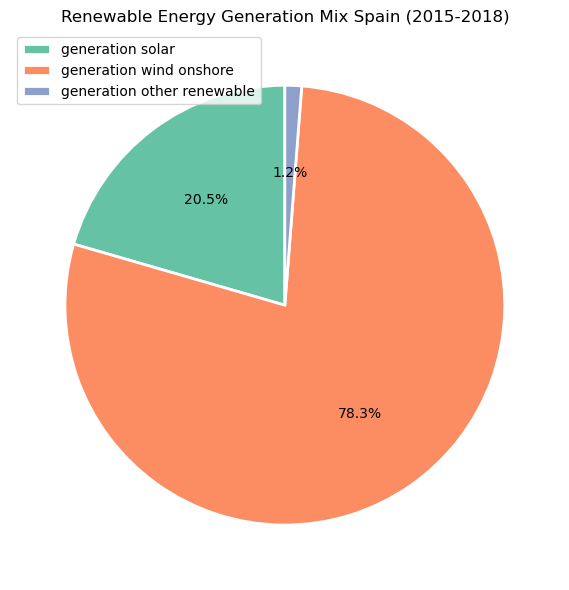

In [19]:
yearly_generation['Renewable'] = (
    yearly_generation['generation solar'] +
    yearly_generation['generation wind onshore'] +
    yearly_generation['generation wind offshore'] +
    yearly_generation['generation other renewable'] +
    yearly_generation['generation geothermal'] +
    yearly_generation['generation marine']
)
yearly_generation_renewable = yearly_generation[['generation solar','generation wind onshore','generation wind offshore','generation other renewable','generation geothermal','generation marine']]
generation_renewables_total = yearly_generation_renewable.sum()
generation_renewables_total = generation_renewables_total[generation_renewables_total > 0]

plt.figure(figsize=(6, 6))
plt.pie(generation_renewables_total.values,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.6,
        labeldistance=0.3,
        colors=sns.color_palette('Set2'),
       wedgeprops={'edgecolor': 'white', 
                    'linewidth': 2},
       labels = None)

plt.title('Renewable Energy Generation Mix Spain (2015-2018)')
plt.legend(generation_renewables_total.index, 
           loc='best')
plt.tight_layout()
plt.savefig('renewable_mix_piechart.png', dpi=150)
plt.show()

## Observations:
- Power generation by onshore winds has the highest proportion within the power generation by renewables. Spain's renewable generation is dominated by onshore wind reflecting its geographical advantage — large open plains and mountain ranges with consistent wind patterns
- Then at second solar is the major contributor in the renewable power generation 
- The absence of geothermal, marine and offshore generation reflects Spain's energy policy focus on proven onshore technologies during 2015-2018, with offshore development still in early stages across Europe during this period.
- Generation by onshore winds and solar are the most important renewable features for price forcasting.

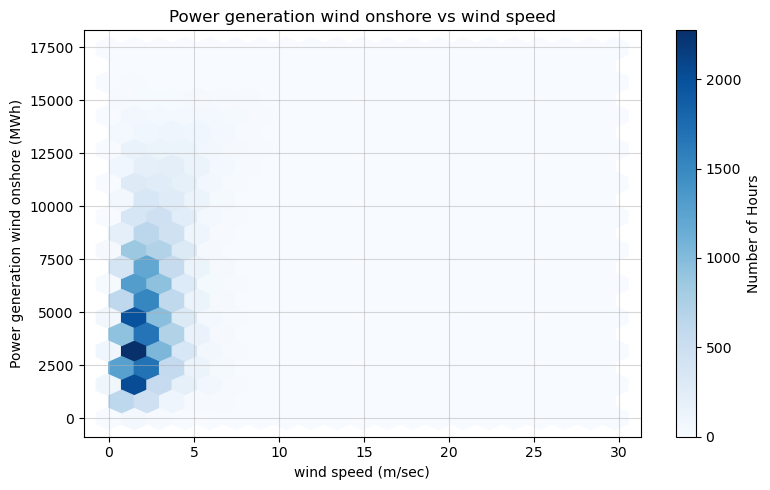

Correlation: 0.324


In [20]:
w_hourly = w_copy.groupby('dt_iso')['wind_speed'].mean().reset_index()
e_hourly = e_copy[['time','generation wind onshore']]
w_hourly.rename(columns = {'dt_iso':'time'}, inplace = True)

merged_wind = pd.merge(e_hourly, w_hourly, on = 'time',how = 'left') # Number of null values checked using merged_wind.isnull().sum())

plt.figure(figsize = (8,5))
plt.hexbin(merged_wind['wind_speed'], merged_wind['generation wind onshore'], cmap = 'Blues', gridsize = 20)
plt.title("Power generation wind onshore vs wind speed")
plt.xlabel("wind speed (m/sec)")
plt.ylabel("Power generation wind onshore (MWh)")
plt.grid(True, alpha = 0.5)
plt.colorbar(label='Number of Hours')
plt.tight_layout()
plt.savefig('wind_generation_vs_wind_speed.png', dpi=150)
plt.show()

corr = merged_wind['wind_speed'].corr(
       merged_wind['generation wind onshore'])
print(f'Correlation: {corr:.3f}')

## Observations:
- Hexbin graph shows highest density between 0-5 m/sec wind speed with generation concentrated at low values. As the wind speed increases beyond 5 m/sec, density decreases (Pearson correlation = 0.324) suggesting geographical mismatch between weather stations and onshore power generation farms.
- Offshore wind generation is zero across all years in the dataset, consistent with Spain's energy infrastructure which had no operational offshore wind capacity during 2015-2018. Generation wind offshore column can be removed in the preprocessing step.

### Q. How Does Generation Mix Affect Price? Or Which Generation Source Has Strongest Correlation With Price?

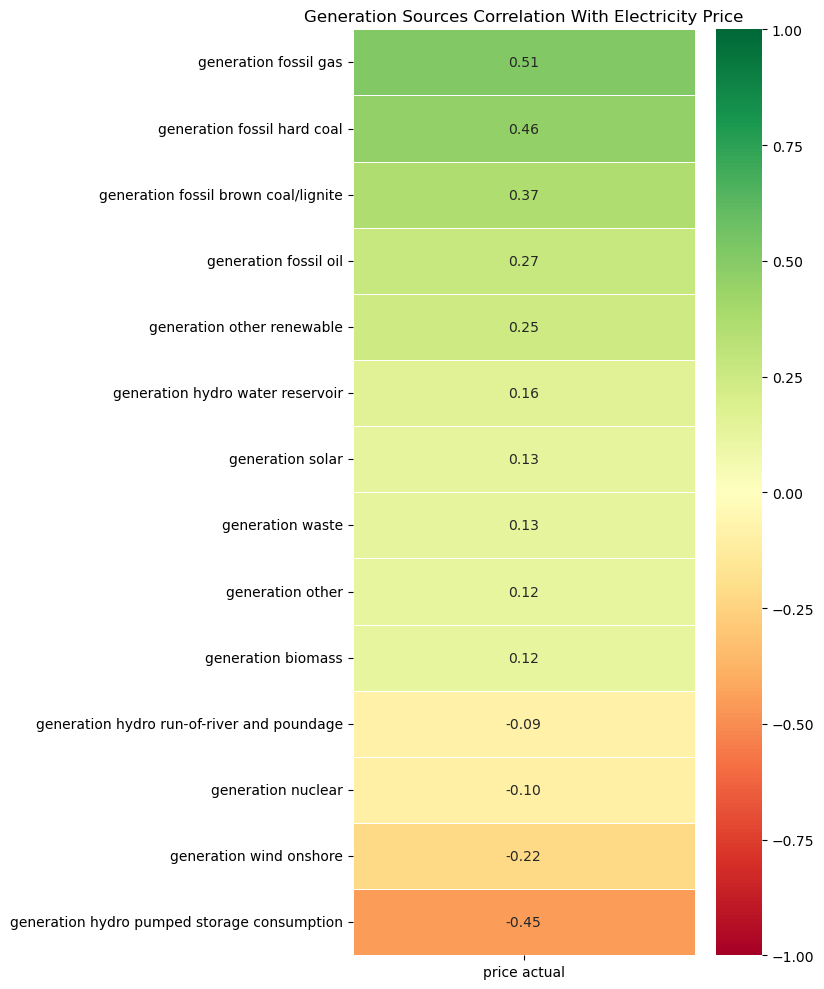

In [21]:
corr_cols = generation_cols + ['price actual']
corr_matrix = e_copy[corr_cols].corr(method='spearman')

price_corr = corr_matrix[['price actual']].drop('price actual')
price_corr = price_corr.sort_values('price actual', ascending=False)
price_corr = price_corr.dropna(how='all')


plt.figure(figsize = (8,10))
sns.heatmap(price_corr,
            annot = True,
            fmt = '.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            vmin=-1,
            vmax=1)
plt.title('Generation Sources Correlation With Electricity Price')
plt.tight_layout()
plt.savefig('generation_price_correlation.png', dpi=150)
plt.show()

### Note:
- Spearman correlation was used instead of Pearson as electricity prices exhibit non-normal distribution due to price spikes, violating Pearson's normality assumption. Spearman captures monotonic relationships without assuming linearity or normality.

### Observations:
- Generation with Fossils and coal shows positive correlation with electricity price, indicating Expensive fossil and coal plants set price during peak demand periods.
- Transition from conventional electricity generation sources to renewable sources, correlation starts to decrease and have negative relation with price. Generation hydro pumped storage consumption and generation wind onshore shows the strongest negative relation with the price.
- This spectrum confirms the merit order effect — as cheaper renewable sources enter the grid they progressively displace expensive fossil plants, suppressing electricity prices. This pattern is central to understanding long term electricity price trends under energy transition.

### Q. Peak Solar Hours vs Price?

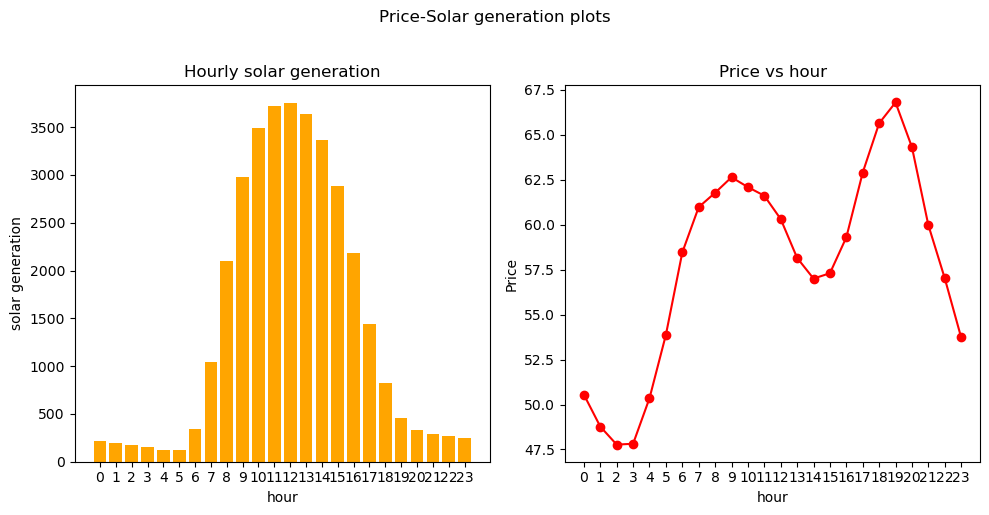

In [22]:
hourly_solar = e_copy.groupby('hour').agg(
    solar_gen=('generation solar', 'mean'),
    price=('price actual', 'mean')
).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

ax[0].bar(hourly_solar['hour'],
            hourly_solar['solar_gen'],
            color='orange')
ax[0].set_xlabel('hour')
ax[0].set_ylabel('solar generation')
ax[0].set_title('Hourly solar generation')
ax[0].set_xticks(range(0, 24))


ax[1].plot(hourly_solar['hour'],
           hourly_solar['price'],
           color='red',
           marker='o')
ax[1].set_xlabel('hour')
ax[1].set_ylabel('Price')
ax[1].set_title('Price vs hour')
ax[1].set_xticks(range(0, 24))

plt.suptitle('Price-Solar generation plots', x=0.5, y=1.02) 
plt.tight_layout()
plt.savefig('Hourly price solar generation plots.png', dpi=150)
plt.show()

In [23]:
morning = e_copy[e_copy['hour'].between(6, 10)]
midday = e_copy[e_copy['hour'].between(11, 15)]
evening = e_copy[e_copy['hour'].between(16, 20)]

print('Morning correlation:', 
      morning['generation solar'].corr(morning['price actual'],method='spearman'))
print('Midday correlation:', 
      midday['generation solar'].corr(midday['price actual'],method='spearman'))
print('Evening correlation:', 
      evening['generation solar'].corr(evening['price actual'],method='spearman'))

Morning correlation: 0.015799624554717007
Midday correlation: -0.009851296022479455
Evening correlation: -0.23173558866126606


### Observation:
- Average solar generation peaks midday (10:00–15:00) when the angle of the sun's rays is closest to vertical.
- During the midday hours, power demands are high. If fossils are the only contributor for power, then Prices would go up. But from Price vs hour plot, we can see Prices dip indicating power generation from solar could be the contributors in meeting the demands.

## Exploratory Data Analysis for Models

In [24]:
n = e_data.duplicated().sum()
print(f"Number of Duplicated row in the energy dataset is {n}.")

n = w_data.duplicated().sum()
print(f"Number of Duplicated row in the weather dataset is {n}.")

Number of Duplicated row in the energy dataset is 0.
Number of Duplicated row in the weather dataset is 21.


### Observation:
- During preprocessing step duplicate rows will automatically deleted when data is transformed and merged as done below.

In [25]:
w_data['dt_iso'] = pd.to_datetime(w_data['dt_iso'], utc = True)
cols_to_drop = ['city_name']
w_clean = w_data.drop(columns = cols_to_drop)

numerical_cols = ['temp','temp_min','temp_max','pressure','humidity','wind_speed','wind_deg','rain_1h','rain_3h','snow_3h','clouds_all']
categorical_cols = ['weather_id','weather_main','weather_description','weather_icon']

w_numerical = w_clean.groupby('dt_iso')[numerical_cols].mean()
w_categorical = w_clean.groupby('dt_iso')[categorical_cols].agg(lambda x: x.mode()[0])

w_final = pd.concat([w_numerical,w_categorical], axis = 1).reset_index()
w_final.rename(columns = {'dt_iso':'time'},inplace = True)

In [26]:
# Merge weather data to energy data
ml_energy = e_data.copy()
ml_energy['time'] = pd.to_datetime(ml_energy['time'], utc = True)
ml_energy = ml_energy[ml_energy['time'].dt.year.isin([2015, 2016, 2017, 2018])]
ml_df = pd.merge(ml_energy, w_final, on='time', how='left')
ml_df.shape

(35063, 44)

#### Note: 
- Weather data was aggregated from city level to country level by averaging numerical variables and taking mode of categorical variables across 5 major Spanish cities — Madrid, Barcelona, Valencia, Seville and Bilbao. This aggregation aligns weather data with Spain's national electricity market pricing which operates at country level.
- Original weather dataset contained 21 duplicate rows at city level. These were resolved during country level aggregation — groupby operation collapsed duplicate timestamps into single representative values through mean and mode aggregation.

### Step: Missing Values Analysis

In [27]:
missing_cnt = ml_df.isnull().sum()[ml_df.isnull().sum() > 0]
missing_pct = (missing_cnt / len(ml_df)*100.0).round(2)
missing_dtype = ml_df[ml_df.columns[ml_df.isnull().sum() > 0]].dtypes

print(f"Energy Dataset")

missing_output = pd.DataFrame({
    'missing count': missing_cnt,
    'missing %': missing_pct,
    'data type': missing_dtype
}).sort_values('missing %', ascending = False)

missing_output

Energy Dataset


,missing count,missing %,data type
forecast wind offshore eday ahead,35063,100.00,float64
generation hydro pumped storage aggregated,35063,100.00,float64
total load actual,36,0.10,float64
generation hydro water reservoir,18,0.05,float64
generation wind onshore,18,0.05,float64
generation wind offshore,18,0.05,float64
generation waste,19,0.05,float64
generation solar,18,0.05,float64
generation other renewable,18,0.05,float64
generation other,18,0.05,float64


### Observation:
- Missing % is more than 70% for forecast wind offshore eday ahead and generation hydro pumped storage aggregated column. Hence these two columns will be dropped in Data preprocessing.
- Missing % of the other columns is less than 1 %. Hence simple imputation technique can be used in data preprocessing.
- Missing % in total load actual column is less than 1%. Values from the total load forcast can be imputed in place of missing data. And Total load forcast column can be dropped to remove multicollinearity.
- There is no missing data in the weather dataset

### Step: Target column distribution

In [28]:
print(ml_df['price actual'].describe())

count    35063.000000
mean        57.883808
std         14.204229
min          9.330000
25%         49.345000
50%         58.020000
75%         68.010000
max        116.800000
Name: price actual, dtype: float64


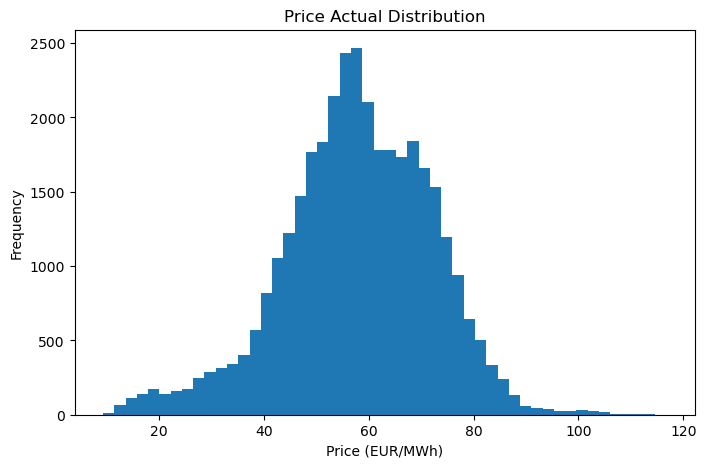

In [29]:
plt.figure(figsize = (8,5))

plt.hist(ml_df['price actual'], bins = 50)
plt.title('Price Actual Distribution')
plt.xlabel('Price (EUR/MWh)')
plt.ylabel('Frequency')
plt.show()

In [30]:
from scipy import stats
skewness = ml_df['price actual'].skew()
print(f'Skewness: {skewness:.3f}')

Skewness: -0.324


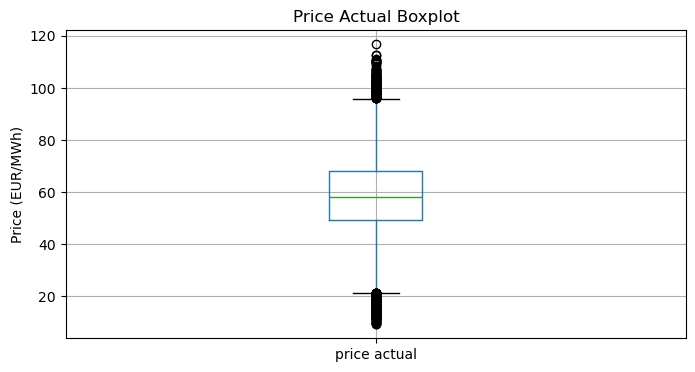

In [31]:
plt.figure(figsize=(8, 4))
ml_df.boxplot(column='price actual')
plt.title('Price Actual Boxplot')
plt.ylabel('Price (EUR/MWh)')
plt.show()

In [32]:
q1 = ml_df['price actual'].quantile(0.25)
q3 = ml_df['price actual'].quantile(0.75)
IQR = q3 - q1
upper_whisker = q3 + IQR*1.5
lower_whisker = q1 - IQR*1.5
outlier_top = ml_df[ml_df['price actual'] > upper_whisker]['price actual'].count()
outlier_bottom = ml_df[ml_df['price actual'] < lower_whisker]['price actual'].count()
total_outlier = outlier_top + outlier_bottom

print(f" Number of outliers below lower whisker: {outlier_bottom} ({outlier_bottom/total_outlier*100.0:.2f}%)")
print(f" Number of outliers above upper whisker: {outlier_top} ({outlier_top/total_outlier*100.0:.2f}%)")
print(f" Total number of outliers: {total_outlier}")

 Number of outliers below lower whisker: 574 (82.23%)
 Number of outliers above upper whisker: 124 (17.77%)
 Total number of outliers: 698


In [33]:
negative_prices = ml_df[ml_df['price actual'] < 0]
print(f'Negative price hours: {len(negative_prices)}')
print(f'Min price: {ml_df["price actual"].min():.2f} EUR/MWh')

Negative price hours: 0
Min price: 9.33 EUR/MWh


### Observation:
- Target column distribution analysis tells the price data is concentrated around 57.88 EUR/MWh with the standard deviation of 14.20. Plot of Price distribution is approximately bell shaped curve with a slight left skewness (skew = -0.324) — mild enough to not significantly impact model performance.
- Total number of outliers is 2% (698), having 82% (574) of outliers on the lower price side while 17.77% (124) of outliers on upper side, suggesting periods of renewable oversupply contributing to extreme low price events

### Step: Numerical feature distribution

array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'generation biomass'}>,
        <Axes: title={'center': 'generation fossil brown coal/lignite'}>,
        <Axes: title={'center': 'generation fossil coal-derived gas'}>,
        <Axes: title={'center': 'generation fossil gas'}>,
        <Axes: title={'center': 'generation fossil hard coal'}>],
       [<Axes: title={'center': 'generation fossil oil'}>,
        <Axes: title={'center': 'generation fossil oil shale'}>,
        <Axes: title={'center': 'generation fossil peat'}>,
        <Axes: title={'center': 'generation geothermal'}>,
        <Axes: title={'center': 'generation hydro pumped storage aggregated'}>,
        <Axes: title={'center': 'generation hydro pumped storage consumption'}>],
       [<Axes: title={'center': 'generation hydro run-of-river and poundage'}>,
        <Axes: title={'center': 'generation hydro water reservoir'}>,
        <Axes: title={'center': 'generation marine'}>,
        <Axes: title=

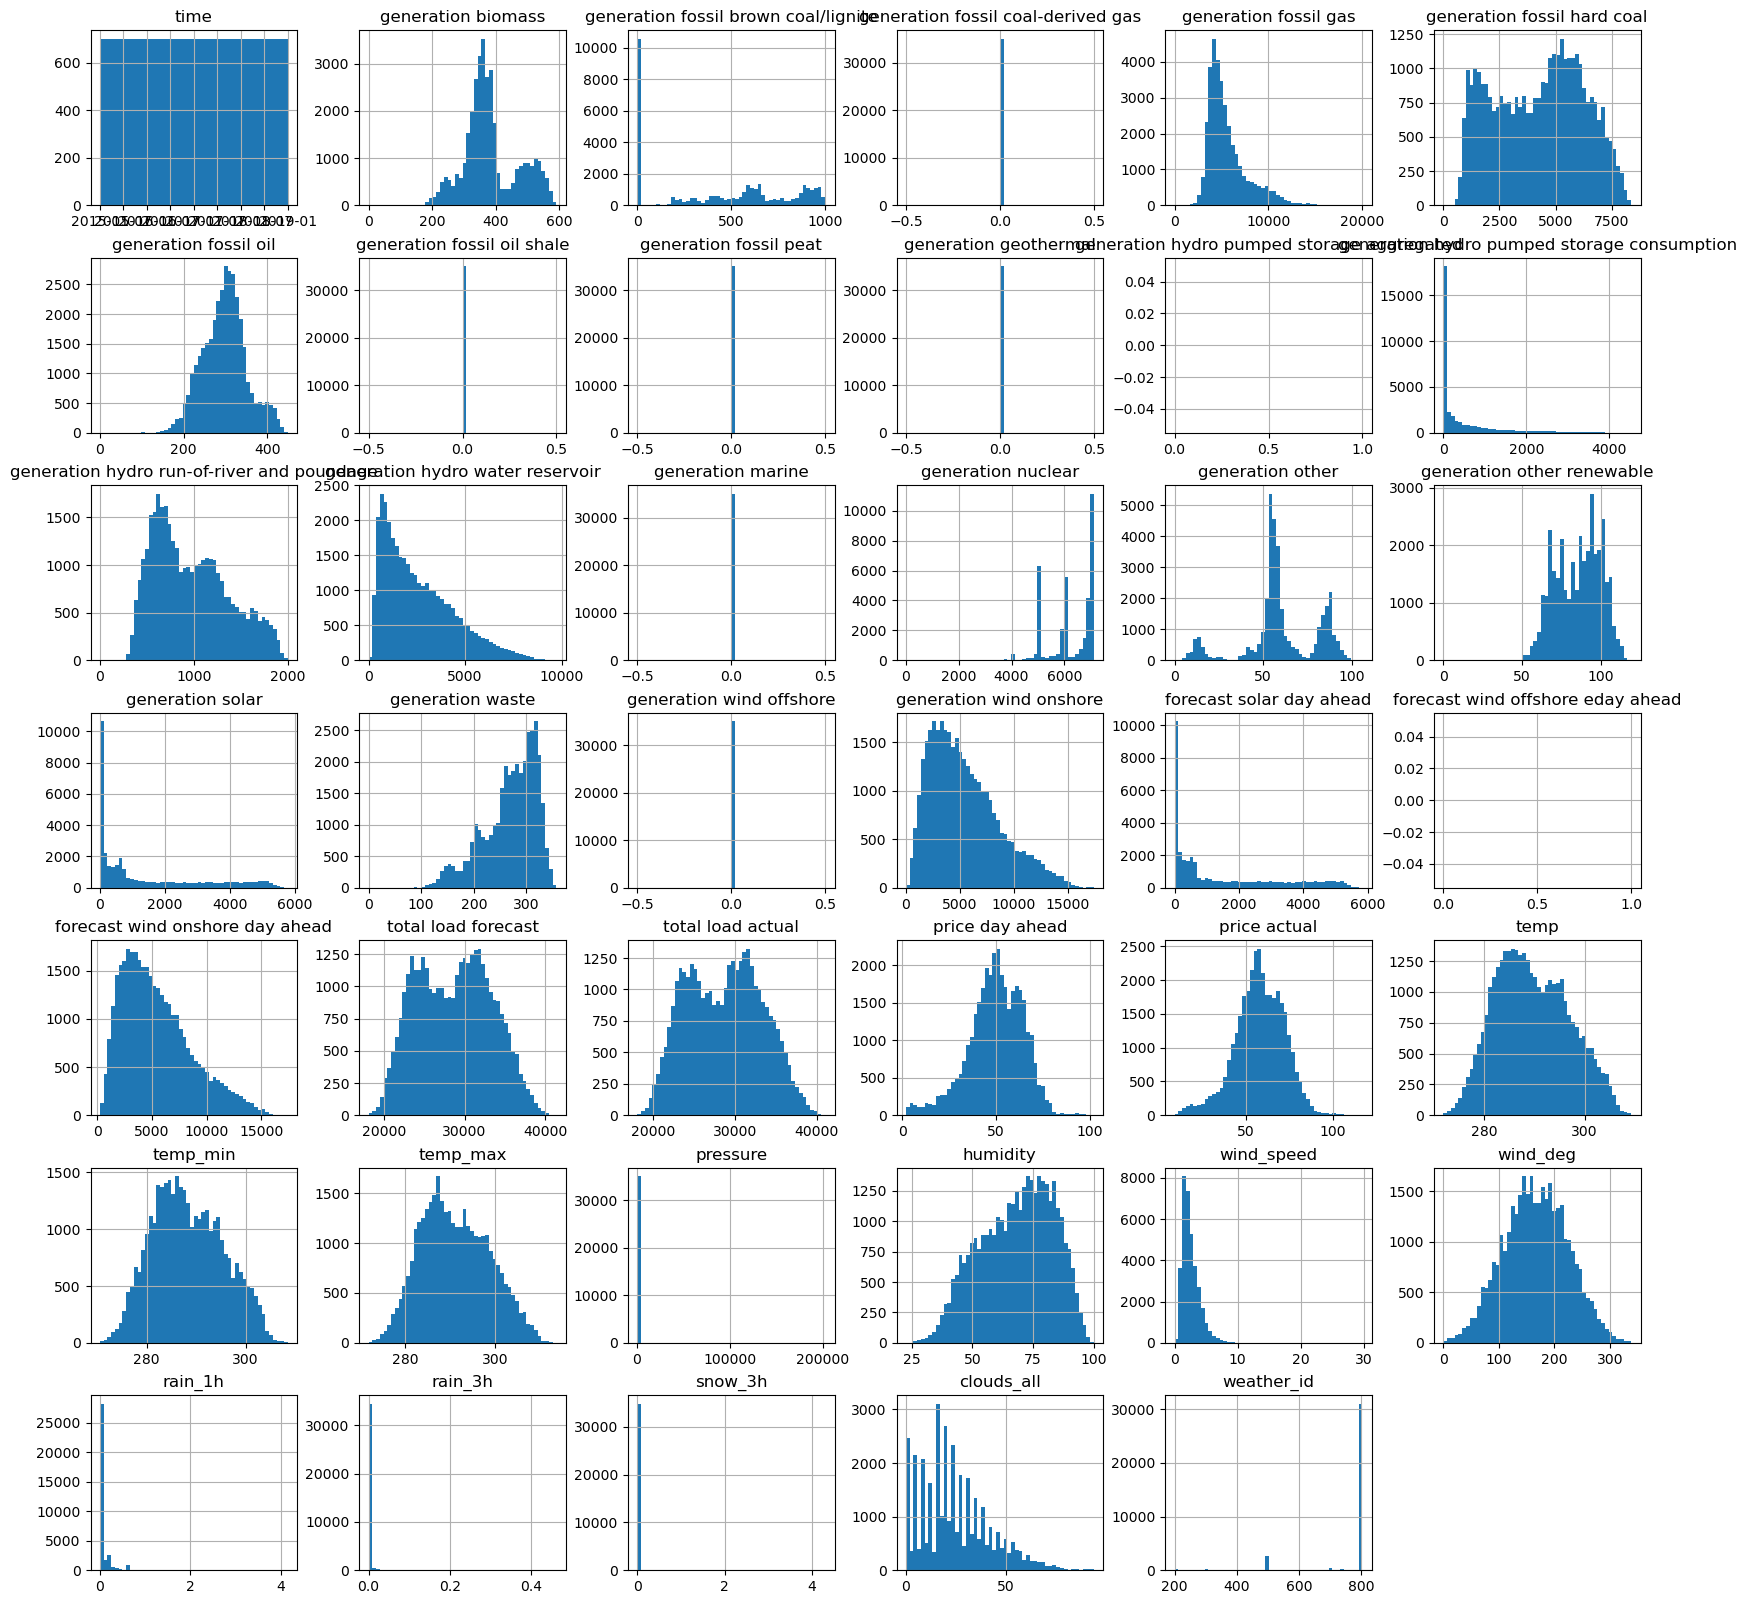

In [34]:
ml_df.hist(bins = 50, figsize = (20,20))

In [35]:
ml_df.describe()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,35044.000000,35045.000000,35045.0,35045.000000,35045.000000,35044.000000,35045.0,35045.0,35045.0,0.0,...,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000
mean,383.511728,448.062605,0.0,5622.759709,4256.049622,298.323679,0.0,0.0,0.0,NaN,...,291.147986,1070.207531,68.216608,2.467543,166.615448,0.073214,0.000386,0.004847,24.738120,766.309414
std,85.354487,354.573079,0.0,2201.857963,1961.626679,52.516373,0.0,0.0,0.0,NaN,...,7.507405,2692.304848,14.890187,1.357768,57.494130,0.202564,0.003360,0.101105,17.306474,102.860675
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,271.941863,812.400000,22.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,285.350000,1012.800000,56.800000,1.400000,126.400000,0.000000,0.000000,0.000000,12.000000,800.000000
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,290.550000,1017.000000,69.800000,2.200000,166.000000,0.000000,0.000000,0.000000,22.400000,800.000000
75%,433.000000,757.000000,0.0,6429.000000,5839.000000,330.000000,0.0,0.0,0.0,NaN,...,296.750000,1021.000000,80.200000,3.200000,207.800000,0.060000,0.000000,0.000000,35.000000,800.000000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,313.548000,202469.000000,100.000000,29.800000,338.000000,4.150000,0.463000,4.300000,93.600000,804.000000


### Observation:
- Here are the list of columns to be dropped as having No data - Generation fossil coal-derived gas, generation fossil oil shale, generation fossil peat, generation geothermal, generation hydro pumped storage aggregated, generation wind offshore, forecast wind offshore eday ahead, and generation marine.

### Step: Skewness and kutosis measurement for each column

In [36]:
num_cols = ml_df.select_dtypes(include=['number']).columns
num_cols.drop('weather_id') ## Weather_id is the categorical column
exclude_cols = [
    'weather_id', 'generation fossil coal-derived gas', 'generation fossil oil shale', 
    'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 
    'generation wind offshore', 'forecast wind offshore eday ahead', 'generation marine'
]
num_cols = num_cols.difference(exclude_cols)

skew_kurt_df = pd.DataFrame({
                    'skewness':ml_df[num_cols].skew(),
                    'Kurtosis':ml_df[num_cols].kurt(),
}).sort_values('skewness', key = abs, ascending = False)

high_skew = skew_kurt_df[skew_kurt_df['skewness'].abs() > 1].index.tolist()
mod_skew = skew_kurt_df[(skew_kurt_df['skewness'].abs() > 0.5) & (skew_kurt_df['skewness'].abs() < 1)].index.tolist()
high_kurt = skew_kurt_df[skew_kurt_df['Kurtosis'].abs() > 1].index.tolist()

print("High Skew (need transformation):", high_skew)
print("Moderate Skew (monitor):", mod_skew)
print("High Kurt:", high_kurt)

High Skew (need transformation): ['rain_3h', 'pressure', 'snow_3h', 'rain_1h', 'generation hydro pumped storage consumption', 'generation fossil gas', 'wind_speed', 'generation solar']
Moderate Skew (monitor): ['forecast solar day ahead', 'generation hydro water reservoir', 'generation waste', 'forecast wind onshore day ahead', 'generation wind onshore', 'clouds_all', 'generation nuclear', 'generation other', 'generation hydro run-of-river and poundage']
High Kurt: ['rain_3h', 'pressure', 'snow_3h', 'rain_1h', 'generation hydro pumped storage consumption', 'generation fossil gas', 'wind_speed', 'generation fossil hard coal', 'generation fossil brown coal/lignite']


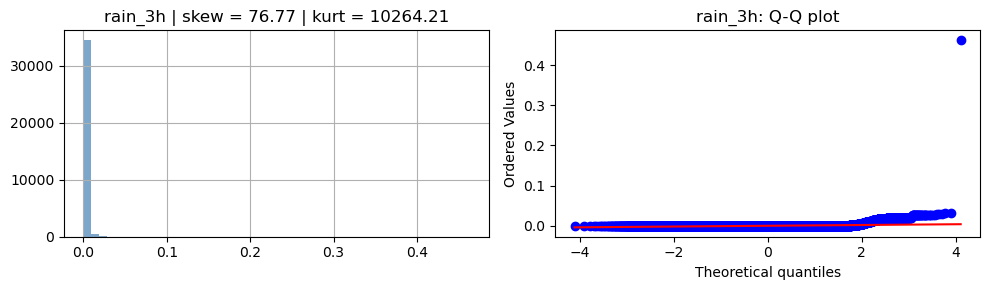

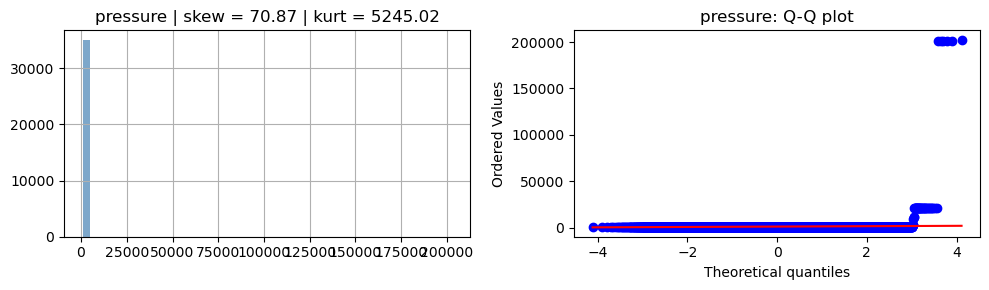

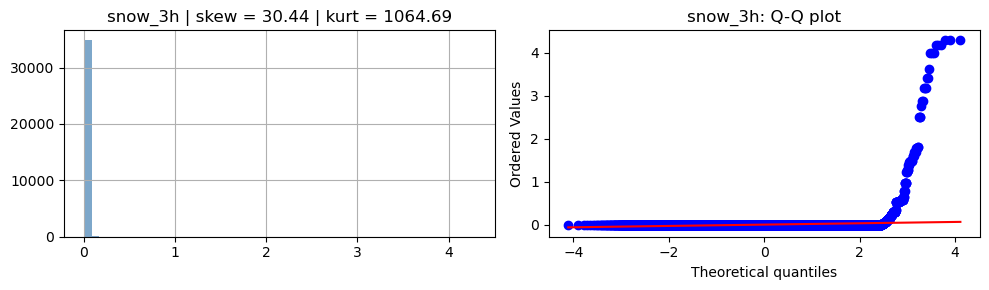

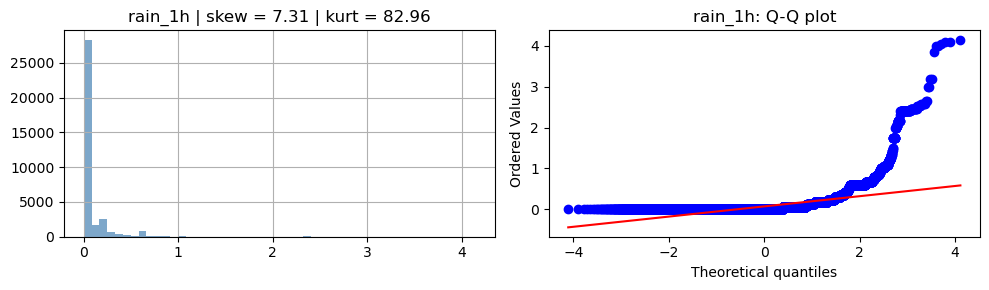

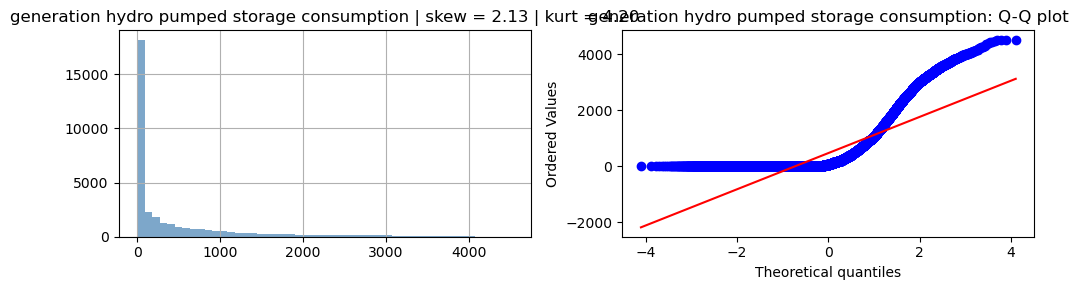

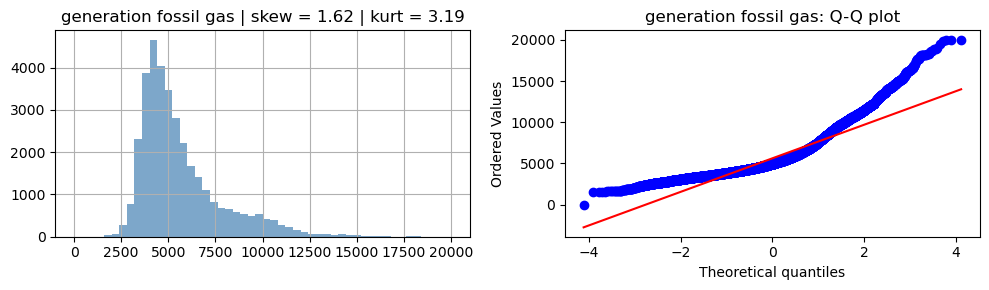

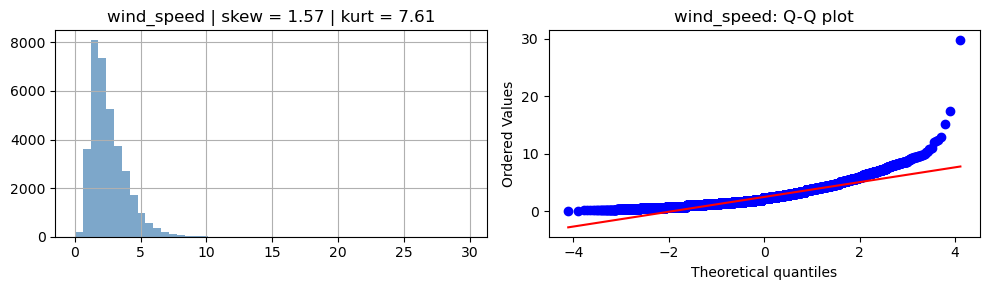

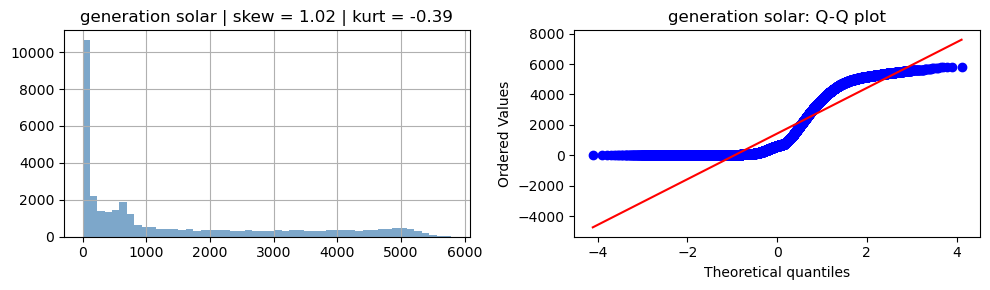

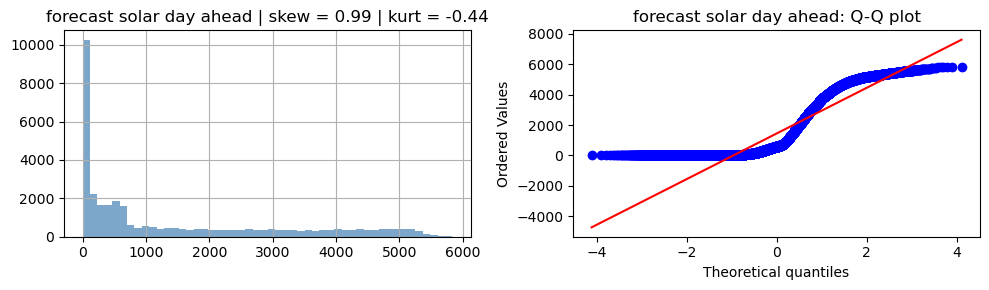

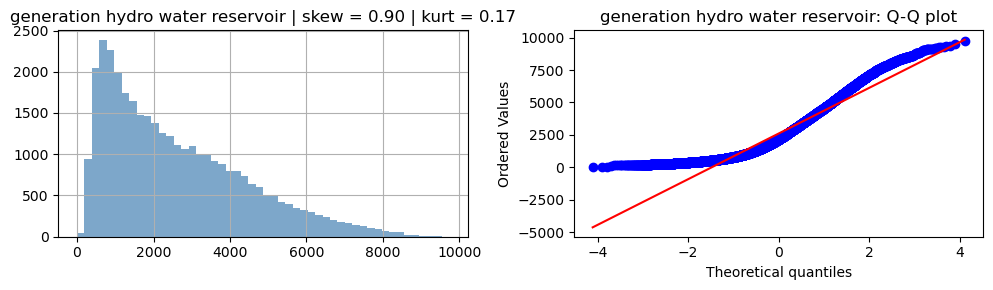

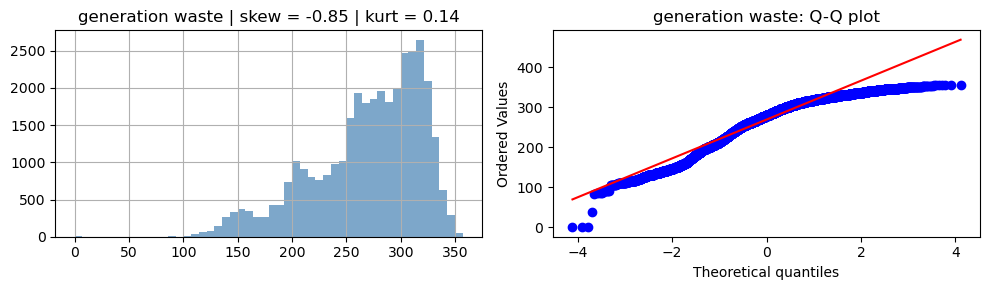

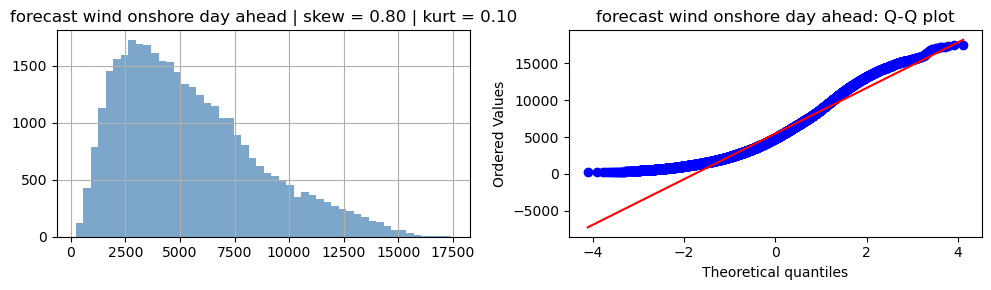

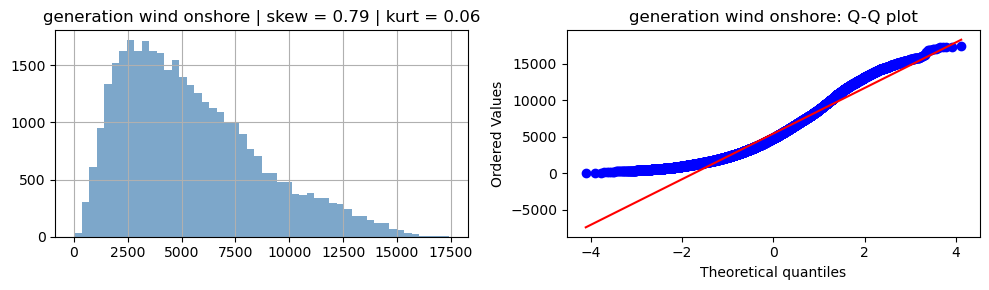

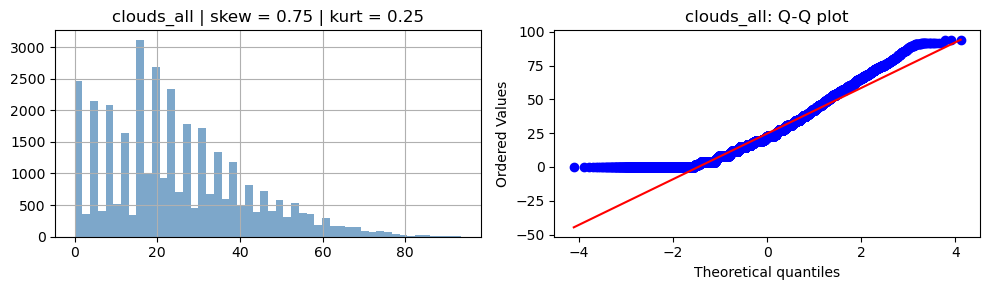

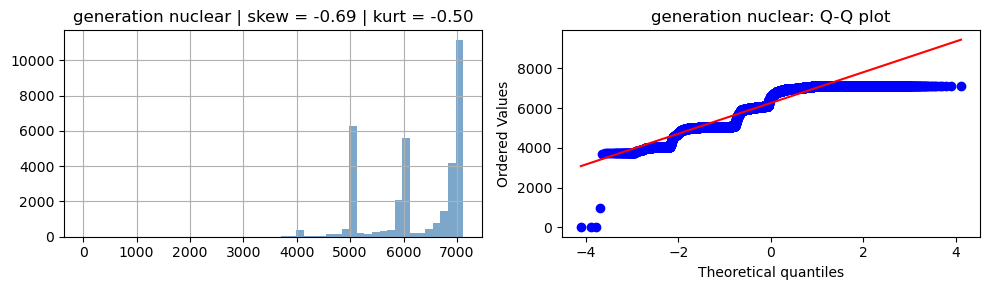

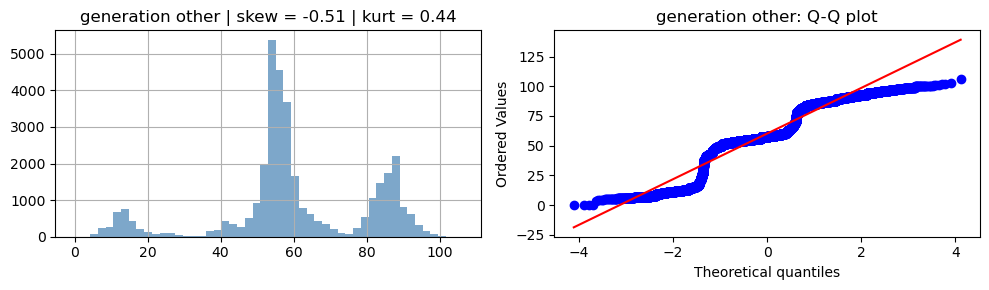

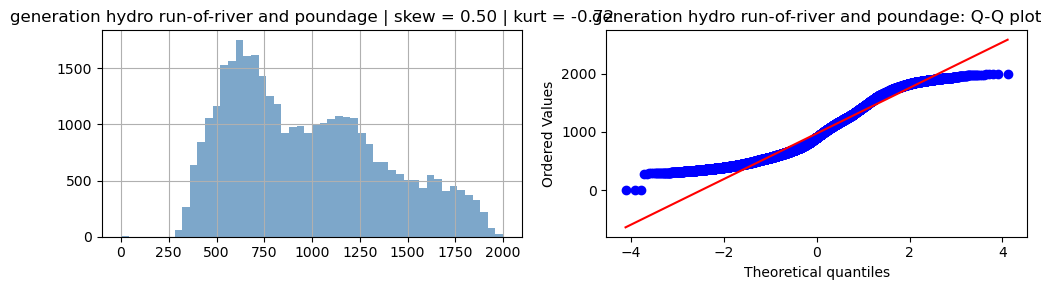

In [38]:
# Q-Q plot
cols_to_plot = [col for col in high_skew + mod_skew if col != 'price actual']

for col in cols_to_plot:
    fig, axes = plt.subplots(1,2,figsize=(10,3))

    #Histogram with KDE
    ml_df[col].hist(ax= axes[0], bins=50, alpha= 0.7, edgecolor=None, color= 'steelblue')
    axes[0].set_title(f'{col} | skew = {ml_df[col].skew():.2f} | kurt = {ml_df[col].kurt():.2f}')

    #Q-Q Plot 
    stats.probplot(ml_df[col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f"{col}: Q-Q plot")

    plt.tight_layout()
    plt.show()

### Obsservation:
- For tree based models — Random Forest and XGBoost — skewness and kurtosis do not affect model performance. Log transformation will be applied exclusively for Linear Regression pipeline on high skew columns

### Step: Outlier detection

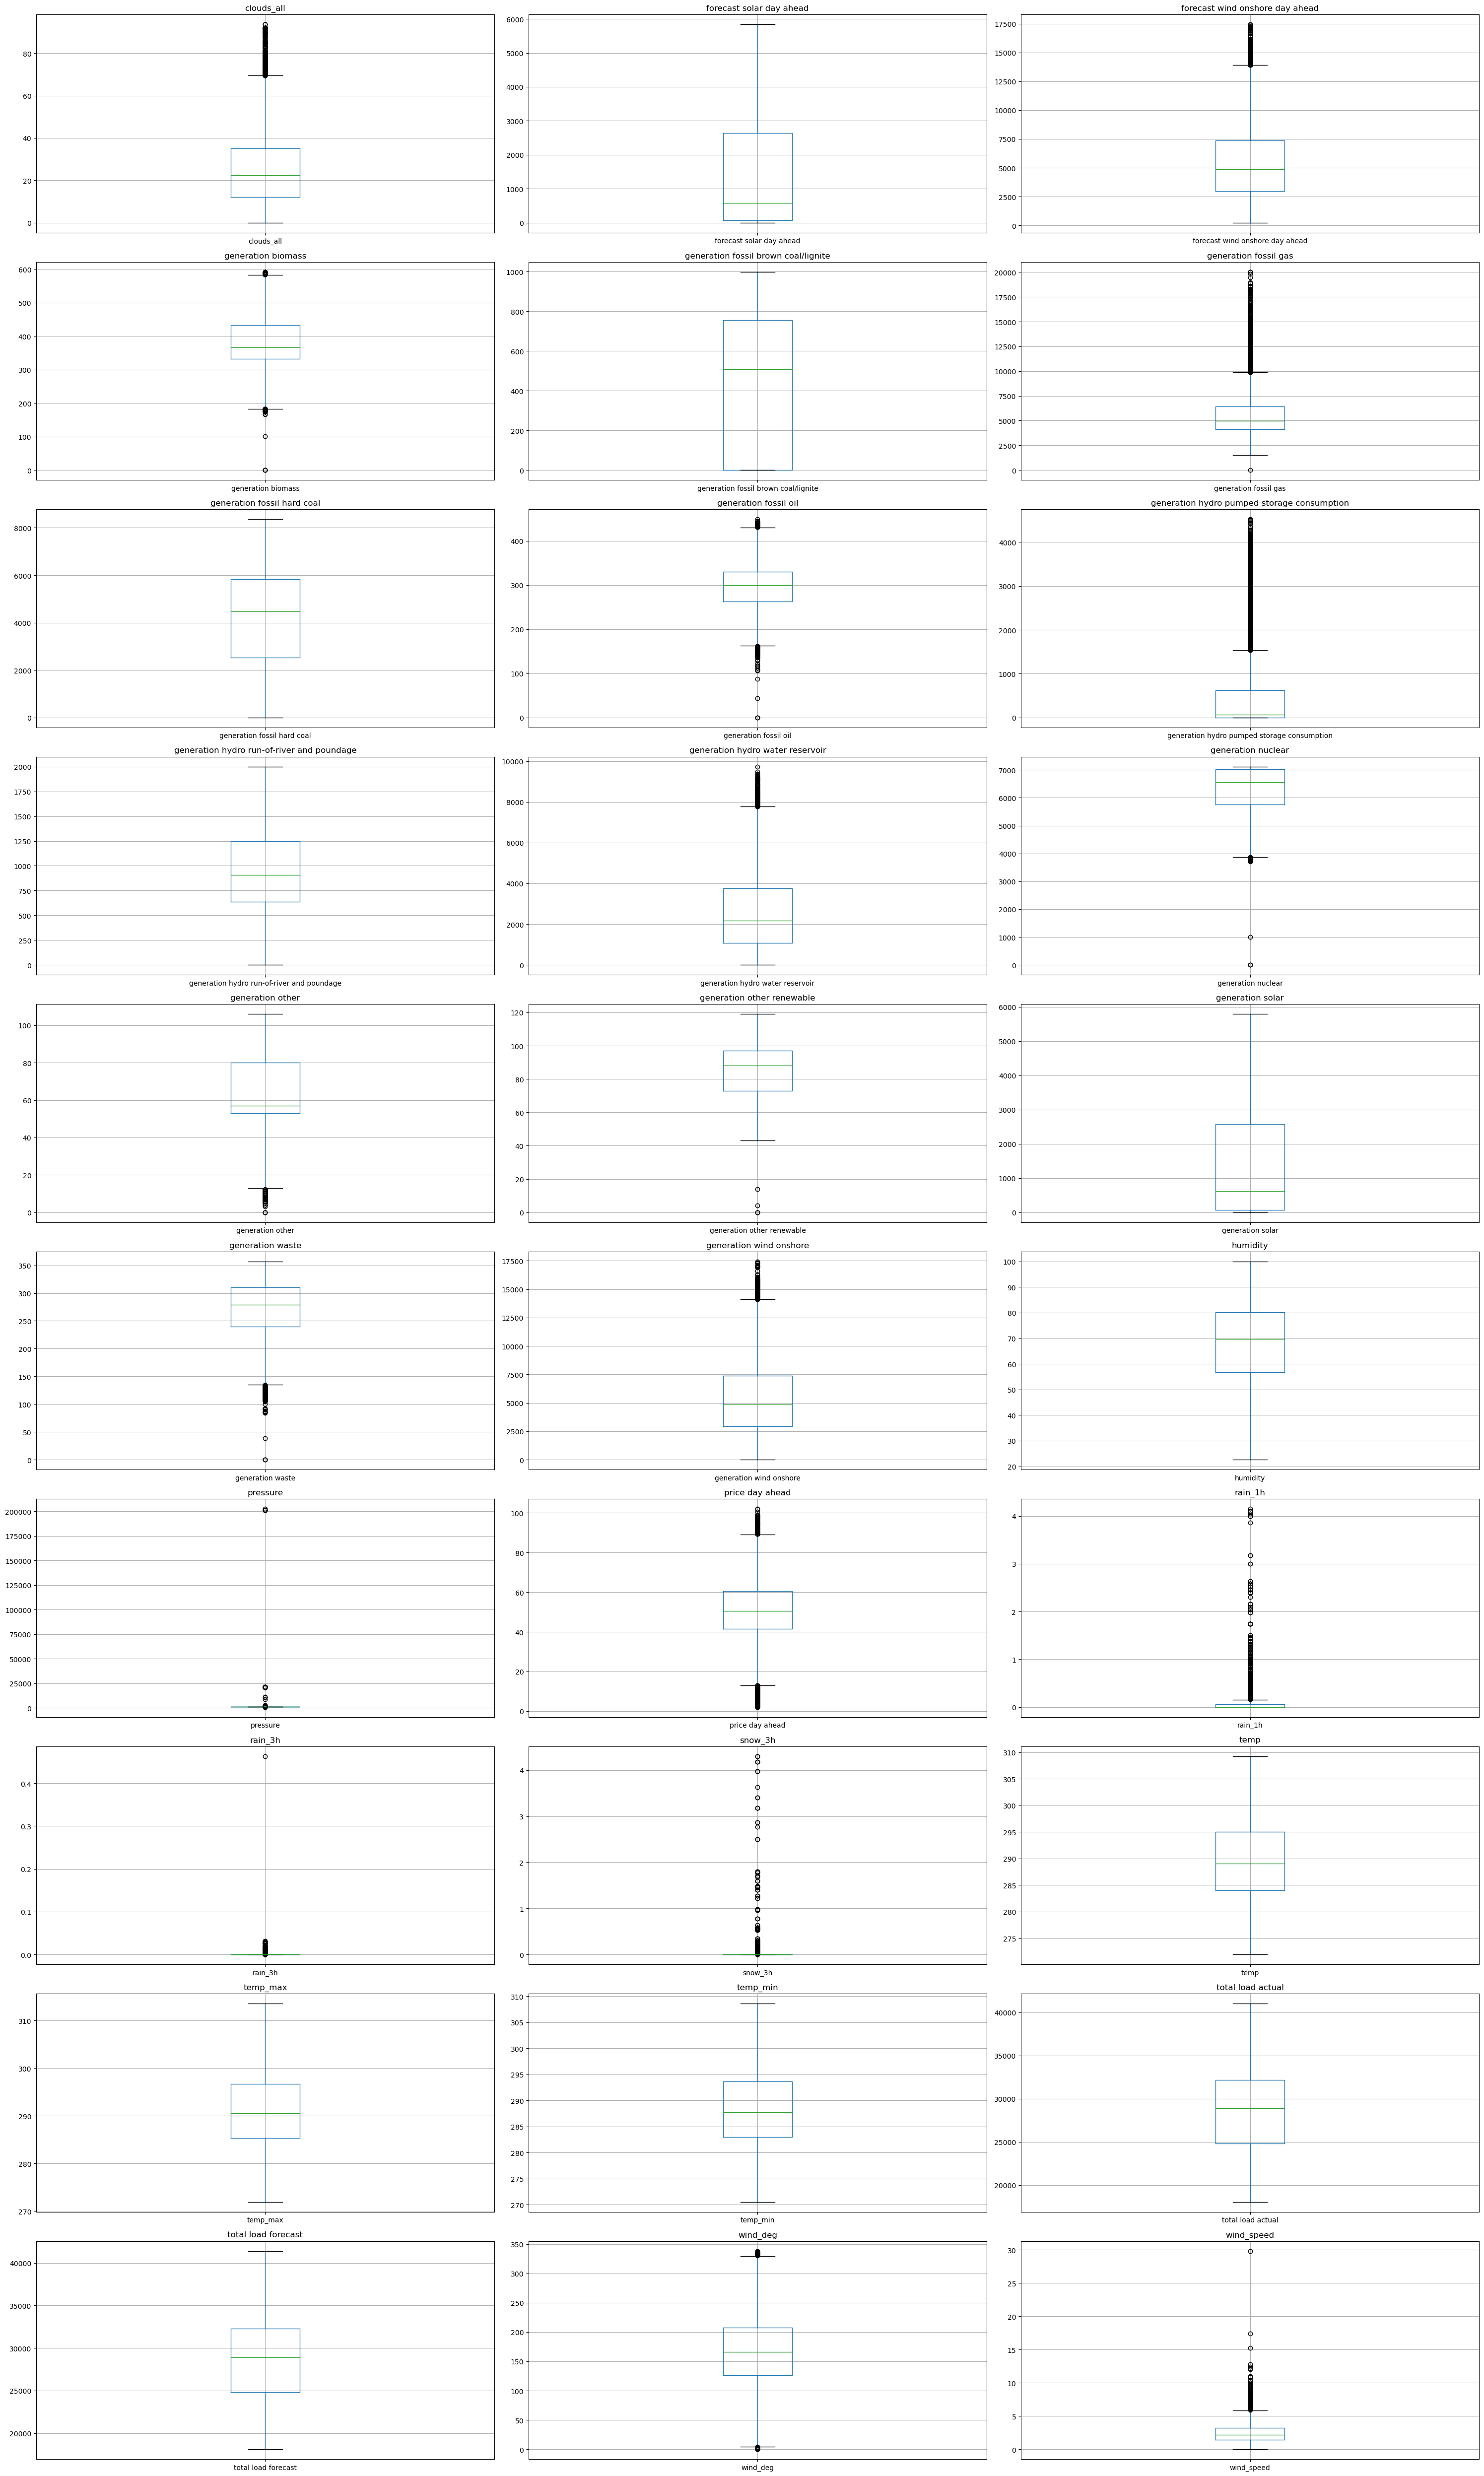

In [39]:
columns = [col for col in num_cols if col != 'price actual']
plt_col = 3
plt_row = (len(columns) + plt_col - 1) // plt_col
fig, axes = plt.subplots(plt_row,plt_col,figsize = (30,50))
axes = axes.flatten()

for i, feature in enumerate(columns):
    ml_df.boxplot(column = feature, ax = axes[i])
    axes[i].set_title(f'{feature}')

plt.tight_layout()
plt.show()

In [40]:
## Counting number of outliers in all numerical columns
record = {}

col = 'actual price'
for col in columns:
    Q1 = ml_df[col].quantile(0.25)
    Q3 = ml_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_whisker = Q3 + 1.5*IQR
    lower_whisker = Q1 - 1.5*IQR

    total_valid = ml_df[col].notna().sum()   # Exclude NaN from column count
    lout_cnt = (ml_df[col] < lower_whisker).sum()
    uout_cnt = (ml_df[col] > upper_whisker).sum()
    total_cnt = lout_cnt + uout_cnt

    if lout_cnt > 0 and uout_cnt == 0:
        direction = 'Lower only'
    elif lout_cnt == 0 and uout_cnt > 0:
        direction = 'Upper only'
    elif lout_cnt > 0 and uout_cnt > 0:
        direction = 'Both sides'
    else:
        direction = 'None'

    record[col] = {
        'lower_outliers' : lout_cnt,
        'upper_outliers' : uout_cnt,
        'Total_outliers' : total_cnt,
        'Outlier %' : round((total_cnt/total_valid)*100,2),
        'Direction' : direction,
        'IQR' : IQR == 0
    }

ml_df_record = pd.DataFrame(record)
ml_df_record

,clouds_all,forecast solar day ahead,forecast wind onshore day ahead,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,...,rain_1h,rain_3h,snow_3h,temp,temp_max,temp_min,total load actual,total load forecast,wind_deg,wind_speed
lower_outliers,0,0,0,46,0,1,0,104,0,0,...,0,0,0,0,0,0,0,0,10,0
upper_outliers,496,0,436,41,0,2184,0,141,3762,0,...,5088,1617,258,0,0,0,0,0,23,830
Total_outliers,496,0,436,87,0,2185,0,245,3762,0,...,5088,1617,258,0,0,0,0,0,33,830
Outlier %,1.41,0.0,1.24,0.25,0.0,6.23,0.0,0.7,10.74,0.0,...,14.51,4.61,0.74,0.0,0.0,0.0,0.0,0.0,0.09,2.37
Direction,Upper only,None,Upper only,Both sides,None,Both sides,None,Both sides,Upper only,None,...,Upper only,Upper only,Upper only,None,None,None,None,None,Both sides,Upper only
IQR,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False


### Note:
- Tree based models — Random Forest and XGBoost — are robust to skewness, outliers and feature scaling, requiring only missing value handling, duplicate removal and categorical encoding. Additional preprocessing steps including log transformation, outlier treatment and StandardScaler were applied exclusively for Linear Regression.

### Step: Categorical feature analysis

In [55]:
object_column = ml_df.select_dtypes(include=['object']).columns
object_column = object_column.append(pd.Index(['weather_id']))

analysis = {}

for col in object_column:
    analysis[col] = {
        "Name" : col ,
        "Unique_count": ml_df[col].nunique(),
        "Unique_values": ml_df[col].unique(),
        "Missing count": ml_df[col].isnull().sum(),
        "Missing %": round(ml_df[col].isnull().sum() / len(ml_df[col]) *100.0,2)
    }

result = pd.DataFrame(analysis)
result

,weather_main,weather_description,weather_icon,weather_id
Name,weather_main,weather_description,weather_icon,weather_id
Unique_count,8,22,21,27
Unique_values,"[clear, clouds, rain, fog, thunderstorm, drizz...","[sky is clear, few clouds, broken clouds, scat...","[01n, 01d, 01, 02, 04n, 04d, 03, 02d, 02n, 04,...","[800, 802, 803, 801, 500, 501, 804, 502, 600, ..."
Missing count,0,0,0,0
Missing %,0.0,0.0,0.0,0.0


In [56]:
#Checking column with high cardinality
result = []

for col in object_column:
    n_unique = ml_df[col].nunique()
    if n_unique > 10:
        result.append(col)

if len(result):
    print(f" These are the columns with high cardinality")
    print(result)
else:
    print(f" There is no column with high cardinality.")

 These are the columns with high cardinality
['weather_description', 'weather_icon', 'weather_id']


In [57]:
#Frequency Distribution

for col in object_column:
    print(f"\n{col}")
    freq = pd.DataFrame({
        'Count' : ml_df[col].value_counts(dropna = False),
        'Freq_%' : round((ml_df[col].value_counts(dropna = False)/len(ml_df)*100),2)
    })
    print(freq)


weather_main
              Count  Freq_%
weather_main               
clear         20615   58.79
clouds        13133   37.46
rain           1155    3.29
mist             88    0.25
fog              51    0.15
drizzle          15    0.04
thunderstorm      5    0.01
haze              1    0.00

weather_description
                              Count  Freq_%
weather_description                        
sky is clear                  19822   56.53
few clouds                     7267   20.73
broken clouds                  3628   10.35
scattered clouds               1914    5.46
light rain                     1401    4.00
moderate rain                   258    0.74
mist                            249    0.71
overcast clouds                 180    0.51
fog                             158    0.45
heavy intensity rain             54    0.15
light intensity drizzle          35    0.10
drizzle                          26    0.07
dust                             22    0.06
light intensity shower ra

In [58]:
print(ml_df['weather_main'].unique())
print(ml_df['weather_main'].nunique())

['clear' 'clouds' 'rain' 'fog' 'thunderstorm' 'drizzle' 'mist' 'haze']
8


### Observation:
- weather_description, weather_icon and weather_id have high cardinality. These columns are reduntant because weather_id is the numerical representation of weather description. And weather description is the detailed description of weather main. Also weather icon is the display code for UI - no meteorological meaning.
- Hence, These three columns will be deleted in data preprocessing step. weather_main will be retained and one hot encoded as it captures meaningful meteorological categories relevant to solar and wind generation.

### Step: Feature target correlation

##### Numerical feature

In [70]:
from scipy import stats

output = {}

for col in num_cols:
    if col == 'price actual':
        continue
        
    clean_df = ml_df[[col, 'price actual']].dropna()
    corr, p_value = stats.spearmanr(clean_df[col], clean_df['price actual'])
    
    if hasattr(corr, "ndim") and corr.ndim > 0:
        corr = corr[0, 1]
        p_value = p_value[0, 1]

    p_status = ''
    corr_status = ''

    if p_value <= 0.05:
        p_status = 'Significant dependency'
    else:
        p_status = 'No significant dependency- consider dropping'

    if abs(corr) > 1.0:
        corr_status = 'Very strong'
    elif 0.7 < abs(corr) <= 1.0:
        corr_status = 'Strong'
    elif 0.4 < abs(corr) <= 0.7:
        corr_status = 'Moderate'
    elif 0.2 < abs(corr) <= 0.4:
        corr_status = 'Weak'
    else:
        corr_status = 'Very_weak-consider dropping'
    

    output[col] = {
        'col_name': col,
        'correlation': round(corr,3),
        'p_value': round(p_value,4),
        'Dependency' : p_status,
        'Strength of dependency' : corr_status
    }

result = pd.DataFrame(output)
result

,clouds_all,forecast solar day ahead,forecast wind onshore day ahead,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,...,rain_1h,rain_3h,snow_3h,temp,temp_max,temp_min,total load actual,total load forecast,wind_deg,wind_speed
col_name,clouds_all,forecast solar day ahead,forecast wind onshore day ahead,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,...,rain_1h,rain_3h,snow_3h,temp,temp_max,temp_min,total load actual,total load forecast,wind_deg,wind_speed
correlation,-0.086,0.144,-0.216,0.122,0.367,0.516,0.46,0.268,-0.447,-0.087,...,-0.11,-0.061,-0.001,0.062,0.04,0.078,0.436,0.436,-0.183,-0.145
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.8438,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,...,Significant dependency,Significant dependency,No significant dependency- consider dropping,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency,Significant dependency
Strength of dependency,Very_weak-consider dropping,Very_weak-consider dropping,Weak,Very_weak-consider dropping,Weak,Moderate,Moderate,Weak,Moderate,Very_weak-consider dropping,...,Very_weak-consider dropping,Very_weak-consider dropping,Very_weak-consider dropping,Very_weak-consider dropping,Very_weak-consider dropping,Very_weak-consider dropping,Moderate,Moderate,Very_weak-consider dropping,Very_weak-consider dropping


In [71]:
print(ml_df['rain_1h'].corr(ml_df['rain_3h']))

0.004971150602799428


In [72]:
print('rain_1h zeros %:', 
      (ml_df['rain_1h'] == 0).sum() / len(ml_df) * 100)
print('rain_3h zeros %:', 
      (ml_df['rain_3h'] == 0).sum() / len(ml_df) * 100)

rain_1h zeros %: 65.11422297008242
rain_3h zeros %: 95.38830105809542


### Observation:
- All features show statistically significant correlation with price (p=0.0) due to large sample size — strength of correlation was therefore used as primary selection criterion.
- Fossil generation sources and total load show strongest positive correlation while hydro pumped storage and wind forecast show strongest negative correlation, consistent with merit order findings from insight EDA.
- Features with near-zero correlation — snow_3h (0.001), temp_max (0.040) — are candidates for removal in feature selection.
- temp_min, temp_max and total load forecast are redundant features and will be dropped in data preprocessing step.
- Rain_3h has 95% values zero, also having weak strength with price actual. Hence strong candidate for dropping in preprocessing step.
- Wind speed and wind degree show weak correlation with price (-0.145 and -0.183 respectively) — likely due to geographic mismatch between city weather stations and wind farm locations. Both features were retained for initial model training with final decision deferred to post-training feature importance analysis.

##### Categorical features

In [75]:
# ANOVA test — checks if price differs across weather categories
from scipy.stats import f_oneway

groups = [ml_df[ml_df['weather_main'] == cat]['price actual'].dropna() 
          for cat in ml_df['weather_main'].unique()]

f_stat, p_value = f_oneway(*groups)
print(f'ANOVA p-value: {p_value:.4f}')

ANOVA p-value: 0.0000


In [76]:
# Eta squared — effect size for ANOVA
# Simple approximation
import numpy as np

grand_mean = ml_df['price actual'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((ml_df['price actual'] - grand_mean)**2)
eta_squared = ss_between / ss_total
print(f'Eta squared: {eta_squared:.4f}')

Eta squared: 0.0049


### Observation:
- Weather main column has good correlation with the price actual. And Eta squared test shows weak strength, indicating small practical effects on the price. However, Feature will be retained as tree based models can extract marginal predictive value from weak features without risk of overfitting.

### Step: Inter-feature correlation or Multicollinearity check 

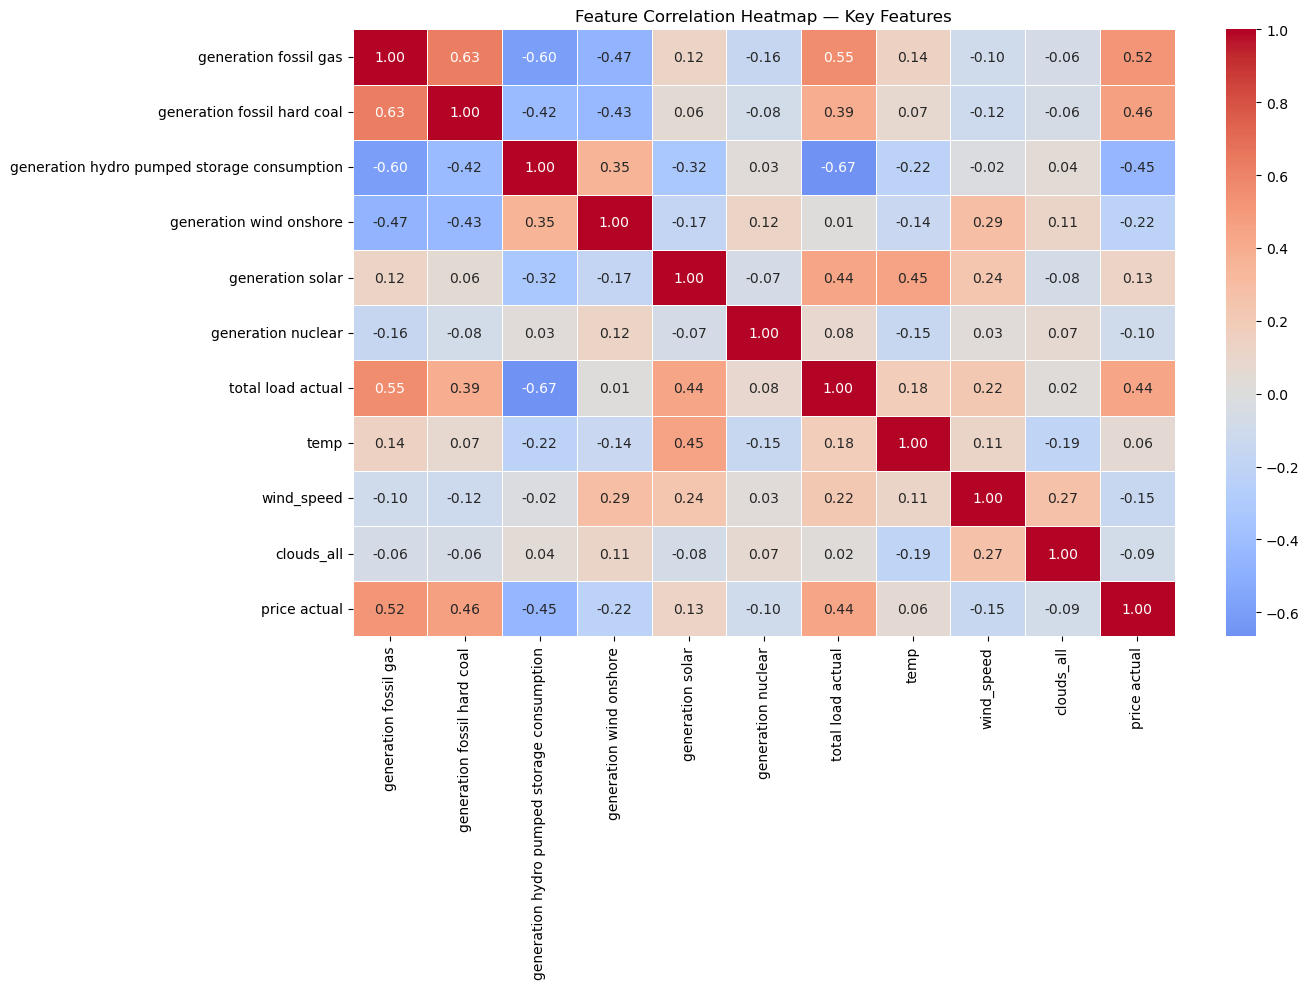

In [85]:
# Select only important columns
important_cols = [
    'generation fossil gas',
    'generation fossil hard coal',
    'generation hydro pumped storage consumption',
    'generation wind onshore',
    'generation solar',
    'generation nuclear',
    'total load actual',
    'temp',
    'wind_speed',
    'clouds_all',
    'price actual'
]

plt.figure(figsize=(14, 10))
sns.heatmap(ml_df[important_cols].corr(method='spearman'),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap — Key Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [84]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = important_cols[:-1]  # exclude target
vif_data['VIF'] = [variance_inflation_factor(
    ml_df[important_cols[:-1]].dropna().values, i)
    for i in range(len(important_cols[:-1]))]

print(vif_data.sort_values('VIF', ascending=False))

                                       feature         VIF
6                            total load actual  151.215608
7                                         temp  107.540777
5                           generation nuclear   59.697063
0                        generation fossil gas   18.025043
1                  generation fossil hard coal   10.001746
3                      generation wind onshore    9.982251
8                                   wind_speed    5.773529
9                                   clouds_all    3.395242
4                             generation solar    2.752548
2  generation hydro pumped storage consumption    2.719559


### Observation:
- Spearman correlation heatmap revealed no severe multicollinearity between features. All features were retained for tree based model training. For Linear Regression, VIF analysis guided additional feature removal 
- VIF analysis reveals multicollinearity concerns for Linear Regression — total load actual (VIF=151), temp (VIF=107) and generation nuclear (VIF=59) show severe inflation. However VIF was evaluated alongside price correlation — features with high VIF but strong price correlation were retained as their predictive value outweighs multicollinearity concerns.
- Features with both high VIF and weak price correlation — specifically temp, temp_max and temp_min — were removed from the Linear Regression pipeline only. Tree based models were trained on full feature set as they are inherently robust to multicollinearity.